# Stage 2B-2 — Root-specific K review (v2)

This notebook is intentionally thin. All clustering, semantic parsing, coherence calculations, diagnostics, and plotting live in `stage2b2_root_k_utils_v2.py`.

### Primary analysis

- **Primary clustering geometry:** row-Spearman correlation-profile distance.
- **Sensitivity geometry:** direct signed consensus distance, \(d = 1-\rho\).
- **Statistical silhouette** across K.
- **Semantic coherence enrichment** for:
  - primitive/root-specific biological identity;
  - tissue-aware semantics;
  - metric-aware semantics.
- **Semantic silhouette** for the same three views is retained as a diagnostic only.
- Explicit penalties against a single giant module and against excessive singleton modules.
- Direct signed within-module correlation is retained as a **guardrail** for row-Spearman-derived modules, because the eventual module scores should still represent directly coordinated features.
- Cross-cohort reproducibility remains a diagnostic and does not enter the K composite.

### Overall K score

\[
KScore = 0.45S_{stat} + 0.30C_{primitive} + 0.10C_{tissue}
       + 0.075B_{large\ cluster} + 0.075B_{singleton}
\]

All components are percentile-ranked across K **within the same panel × prep root × distance mode** before weighting.

Metric-aware coherence and all semantic-silhouette measures are shown for interpretation but have **zero weight** in the composite.

Candidate-cap stability is intentionally deferred to a later sensitivity analysis, so this notebook only evaluates the fixed Stage 2A4/2A5 feature universe.

In [4]:
# ============================================================
# Cell 1 — Paths and review settings
# ============================================================

from pathlib import Path

MODULE_DIR = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules2"
)

STAGE2B1_ROOT = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/"
    "stage2_root_meta_modules_v1/stage2b1_root_consensus_v1"
)

OUT_ROOT = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/"
    "stage2_root_meta_modules_v1/stage2b2_root_k_review_v2"
)

UTILS_PATH = MODULE_DIR / "stage2b2_root_k_utils_v2.py"
PARSER_PATH = MODULE_DIR / "stage2_feature_parser_v8.py"

# Primary first; direct signed is retained as sensitivity.
DISTANCE_MODES = ["row_spearman", "direct_signed"]
PRIMARY_MODE = "row_spearman"

K_MIN = 2
K_MAX = 30
LINKAGE_METHOD = "average"

# Used only to characterize the semantic-coherence null distribution.
N_SEMANTIC_PERMUTATIONS = 100
RANDOM_SEED = 20260818

# Primary K composite requested for the final review.
K_SCORE_WEIGHTS = {
    "stat_silhouette": 0.45,
    "primitive_coherence": 0.30,
    "tissue_coherence": 0.10,
    "metric_coherence": 0.00,   # diagnostic only
    "cluster_balance": 0.075,   # rewards smaller largest-cluster fraction
    "non_singleton": 0.075,     # rewards fewer singleton modules
}

# Soft review warnings / parsimonious-K guardrails, not hard clustering filters.
REVIEW_THRESHOLDS = {
    "max_cluster_fraction": 0.50,
    "singleton_fraction": 0.25,
    "within_best_fraction": 0.95,

    # Direct signed cohesion guardrail for row-Spearman modules.
    # These do not enter the composite score.
    "min_q25_module_mean_consensus_rho": 0.00,
    "min_median_module_fraction_positive_pairs": 0.60,
}

TOP_K_HEATMAPS = 3

print("Primary geometry:", PRIMARY_MODE)
print("K-score weights sum:", sum(K_SCORE_WEIGHTS.values()))
print("Output:", OUT_ROOT)

Primary geometry: row_spearman
K-score weights sum: 0.9999999999999999
Output: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2


In [5]:
# ============================================================
# Cell 2 — Load helper functions
# ============================================================

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("stage2b2_utils", UTILS_PATH)
b2 = importlib.util.module_from_spec(spec)
sys.modules["stage2b2_utils"] = b2
spec.loader.exec_module(b2)

print("Loaded:", UTILS_PATH)

Loaded: /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules2/stage2b2_root_k_utils_v2.py


In [6]:
# ============================================================
# Cell 3 — Preflight Stage 2B-1 outputs
# ============================================================

import pandas as pd
from IPython.display import display

manifest = b2.load_b1_manifest(STAGE2B1_ROOT)

check_rows = []
for _, row in manifest.iterrows():
    try:
        root_dir = b2._find_root_dir(STAGE2B1_ROOT, row.to_dict())
        done = (root_dir / ".done").exists()
        consensus_exists = (
            root_dir /
            "consensus_signed_spearman_support_filtered_clustering.parquet"
        ).exists()
    except Exception:
        root_dir = None
        done = False
        consensus_exists = False

    check_rows.append({
        "panel": row["panel"],
        "feature_source": row["feature_source"],
        "stage2b1_done": done,
        "consensus_exists": consensus_exists,
        "root_dir": str(root_dir) if root_dir else "",
    })

preflight = pd.DataFrame(check_rows)
display(preflight)

if not preflight["consensus_exists"].all():
    raise RuntimeError(
        "At least one Stage 2B-1 consensus is not ready. "
        "Finish Stage 2B-1 before running the K review."
    )

,panel,feature_source,stage2b1_done,consensus_exists,root_dir
0,AR,AR_checkpoint_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
1,AR,AR_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
2,AR,compartment,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
3,AR,compartment_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
4,AR,phenotype_only,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
5,BT,compartment,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
6,BT,phenotype_only,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...


In [7]:
# ============================================================
# Cell 4 — Run complete Stage 2B-2 review
# ============================================================

review = b2.run_full_stage2b2_review(
    stage2b1_root=STAGE2B1_ROOT,
    output_root=OUT_ROOT,
    parser_path=PARSER_PATH,
    distance_modes=DISTANCE_MODES,
    primary_mode=PRIMARY_MODE,
    k_min=K_MIN,
    k_max=K_MAX,
    linkage_method=LINKAGE_METHOD,
    n_semantic_permutations=N_SEMANTIC_PERMUTATIONS,
    random_seed=RANDOM_SEED,
    score_weights=K_SCORE_WEIGHTS,
    review_thresholds=REVIEW_THRESHOLDS,
    top_heatmaps=TOP_K_HEATMAPS,
)

print("\nDone.")
print("Output root:", OUT_ROOT)

if not review["errors"].empty:
    print("\nRoots with errors:")
    display(review["errors"])
else:
    print("All roots completed successfully.")

[STAGE2B2] AR / AR_checkpoint_state
[STAGE2B2] AR / AR_state
[STAGE2B2] AR / compartment
[STAGE2B2] AR / compartment_state
[STAGE2B2] AR / phenotype_only
[STAGE2B2] BT / compartment
[STAGE2B2] BT / phenotype_only

Done.
Output root: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2
All roots completed successfully.


In [8]:
# ============================================================
# Cell 5 — Global recommendation table
# ============================================================

manual_review = review["manual_review"].copy()
display(manual_review)

print("Saved:")
for name in [
    "stage2b2_manual_k_review_template.csv",
    "all_panel_root_k_recommendations.csv",
    "all_panel_root_k_diagnostics.csv",
    "primary_mode_top5_k_per_root.csv",
]:
    print(OUT_ROOT / name)

,panel,feature_source,n_features,primary_distance_mode,primary_best_score_k,primary_recommended_k,primary_recommended_score,primary_stat_silhouette,primary_primitive_coherence_enrichment,primary_tissue_coherence_enrichment,primary_metric_coherence_enrichment,primary_max_cluster_fraction,primary_singleton_fraction,primary_q25_module_mean_consensus_rho,primary_median_module_fraction_positive_pairs,primary_passes_direct_cohesion_review,primary_cross_cohort_median_rho,sensitivity_mode_recommended_ks,manual_selected_k,manual_notes
0,AR,AR_checkpoint_state,22,row_spearman,7,7,0.768750,0.658783,0.006139,0.050372,0.052424,0.500000,0.285714,0.523642,1.0,True,0.650278,direct_signed:2,,
1,AR,AR_state,107,row_spearman,30,30,0.914655,0.520830,0.279408,0.311551,0.322495,0.112150,0.266667,0.608963,1.0,True,0.644007,direct_signed:28,,
2,AR,compartment,37,row_spearman,13,13,0.776724,0.700082,0.346298,0.343182,0.368068,0.189189,0.307692,0.764534,1.0,True,0.840578,direct_signed:19,,
3,AR,compartment_state,93,row_spearman,26,24,0.743966,0.473987,0.234601,0.255580,0.278426,0.172043,0.291667,0.540449,1.0,True,0.636148,direct_signed:29,,
4,AR,phenotype_only,48,row_spearman,27,26,0.690086,0.495028,0.297090,0.318037,0.378135,0.104167,0.576923,0.788091,1.0,True,0.836352,direct_signed:18,,
5,BT,compartment,47,row_spearman,23,23,0.934052,0.615373,0.381112,0.397262,0.402999,0.106383,0.391304,0.823792,1.0,True,0.869643,direct_signed:24,,
6,BT,phenotype_only,110,row_spearman,27,27,0.860345,0.510687,0.148688,0.148655,0.234236,0.218182,0.296296,0.687238,1.0,True,0.721085,direct_signed:29,,


Saved:
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2/stage2b2_manual_k_review_template.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2/all_panel_root_k_recommendations.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2/all_panel_root_k_diagnostics.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v2/primary_mode_top5_k_per_root.csv


## How to review one root

For the **row-Spearman primary solution**, I suggest reviewing K in this order:

1. **Statistical silhouette** — is the correlation-profile clustering structurally separated?
2. **Primitive coherence enrichment** — does the grouping recover biologically coherent root-specific identities more than random partitions of the same sizes?
3. **Tissue-aware coherence enrichment** — useful additional evidence, but deliberately lower weight because it overlaps with primitive semantics.
4. **Module-size health** — avoid solutions dominated by one very large module or many singletons.
5. **Direct signed cohesion guardrail** — row-Spearman groups features with similar network neighborhoods, but the resulting modules should still show positive direct coordination if they will later be scored together.
6. **Cross-cohort reproducibility** — diagnostic confirmation that the consensus structure is not driven by one cohort.
7. Compare with **direct-signed sensitivity clustering** and inspect the candidate-K heatmaps before freezing K.

Metric-aware coherence and semantic silhouettes are retained primarily to understand the solution, not to drive K.

,requested_k,k_composite_score,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,metric_aware_semantic_silhouette,primitive_coherence_enrichment,tissue_aware_coherence_enrichment,metric_aware_coherence_enrichment,max_cluster_fraction,singleton_fraction,median_module_mean_consensus_rho,q25_module_mean_consensus_rho,median_module_fraction_positive_pairs,passes_direct_cohesion_review,median_module_cohort_mean_rho,fraction_module_cohort_positive,within_best_fraction,passes_size_review
0,30,0.914655,0.520830,0.077633,0.070357,0.033934,0.279408,0.311551,0.322495,0.112150,0.266667,0.696570,0.608963,1.000000,True,0.644007,0.990476,True,False
1,26,0.778879,0.492708,0.037358,0.022320,-0.014515,0.219081,0.229716,0.239135,0.177570,0.192308,0.653520,0.584608,1.000000,True,0.632006,0.990000,False,True
2,28,0.771552,0.491333,0.042873,0.027835,-0.007605,0.219449,0.230915,0.239499,0.177570,0.250000,0.653520,0.605033,1.000000,True,0.636683,0.990000,False,True
3,29,0.733190,0.489357,0.059500,0.044463,0.004802,0.219145,0.230854,0.238946,0.177570,0.275862,0.695173,0.605033,1.000000,True,0.646443,0.990000,False,False
4,27,0.695259,0.484664,0.044834,0.029797,-0.009101,0.218931,0.229683,0.238864,0.177570,0.259259,0.651563,0.571282,1.000000,True,0.633646,0.989583,False,False
5,25,0.686638,0.475638,0.006609,-0.003257,-0.049185,0.210211,0.222146,0.229649,0.177570,0.200000,0.646974,0.527410,1.000000,True,0.628394,0.989583,False,True
6,24,0.604741,0.444122,-0.051924,-0.073840,-0.136019,0.171579,0.177243,0.178790,0.177570,0.208333,0.632228,0.523516,1.000000,True,0.608868,0.989011,False,True
7,23,0.577155,0.442499,-0.050324,-0.070140,-0.133068,0.169456,0.178218,0.179867,0.177570,0.217391,0.638285,0.544630,1.000000,True,0.606650,0.988372,False,True
8,7,0.566379,0.518200,-0.000178,-0.026641,-0.102923,0.040582,0.048278,0.042200,0.457944,0.000000,0.462567,0.409639,1.000000,True,0.425636,0.970588,False,True
9,8,0.554310,0.496740,-0.003300,-0.028345,-0.101202,0.044224,0.056841,0.048763,0.420561,0.000000,0.469904,0.441557,1.000000,True,0.457095,0.973684,False,True



 00_k_review_dashboard.png


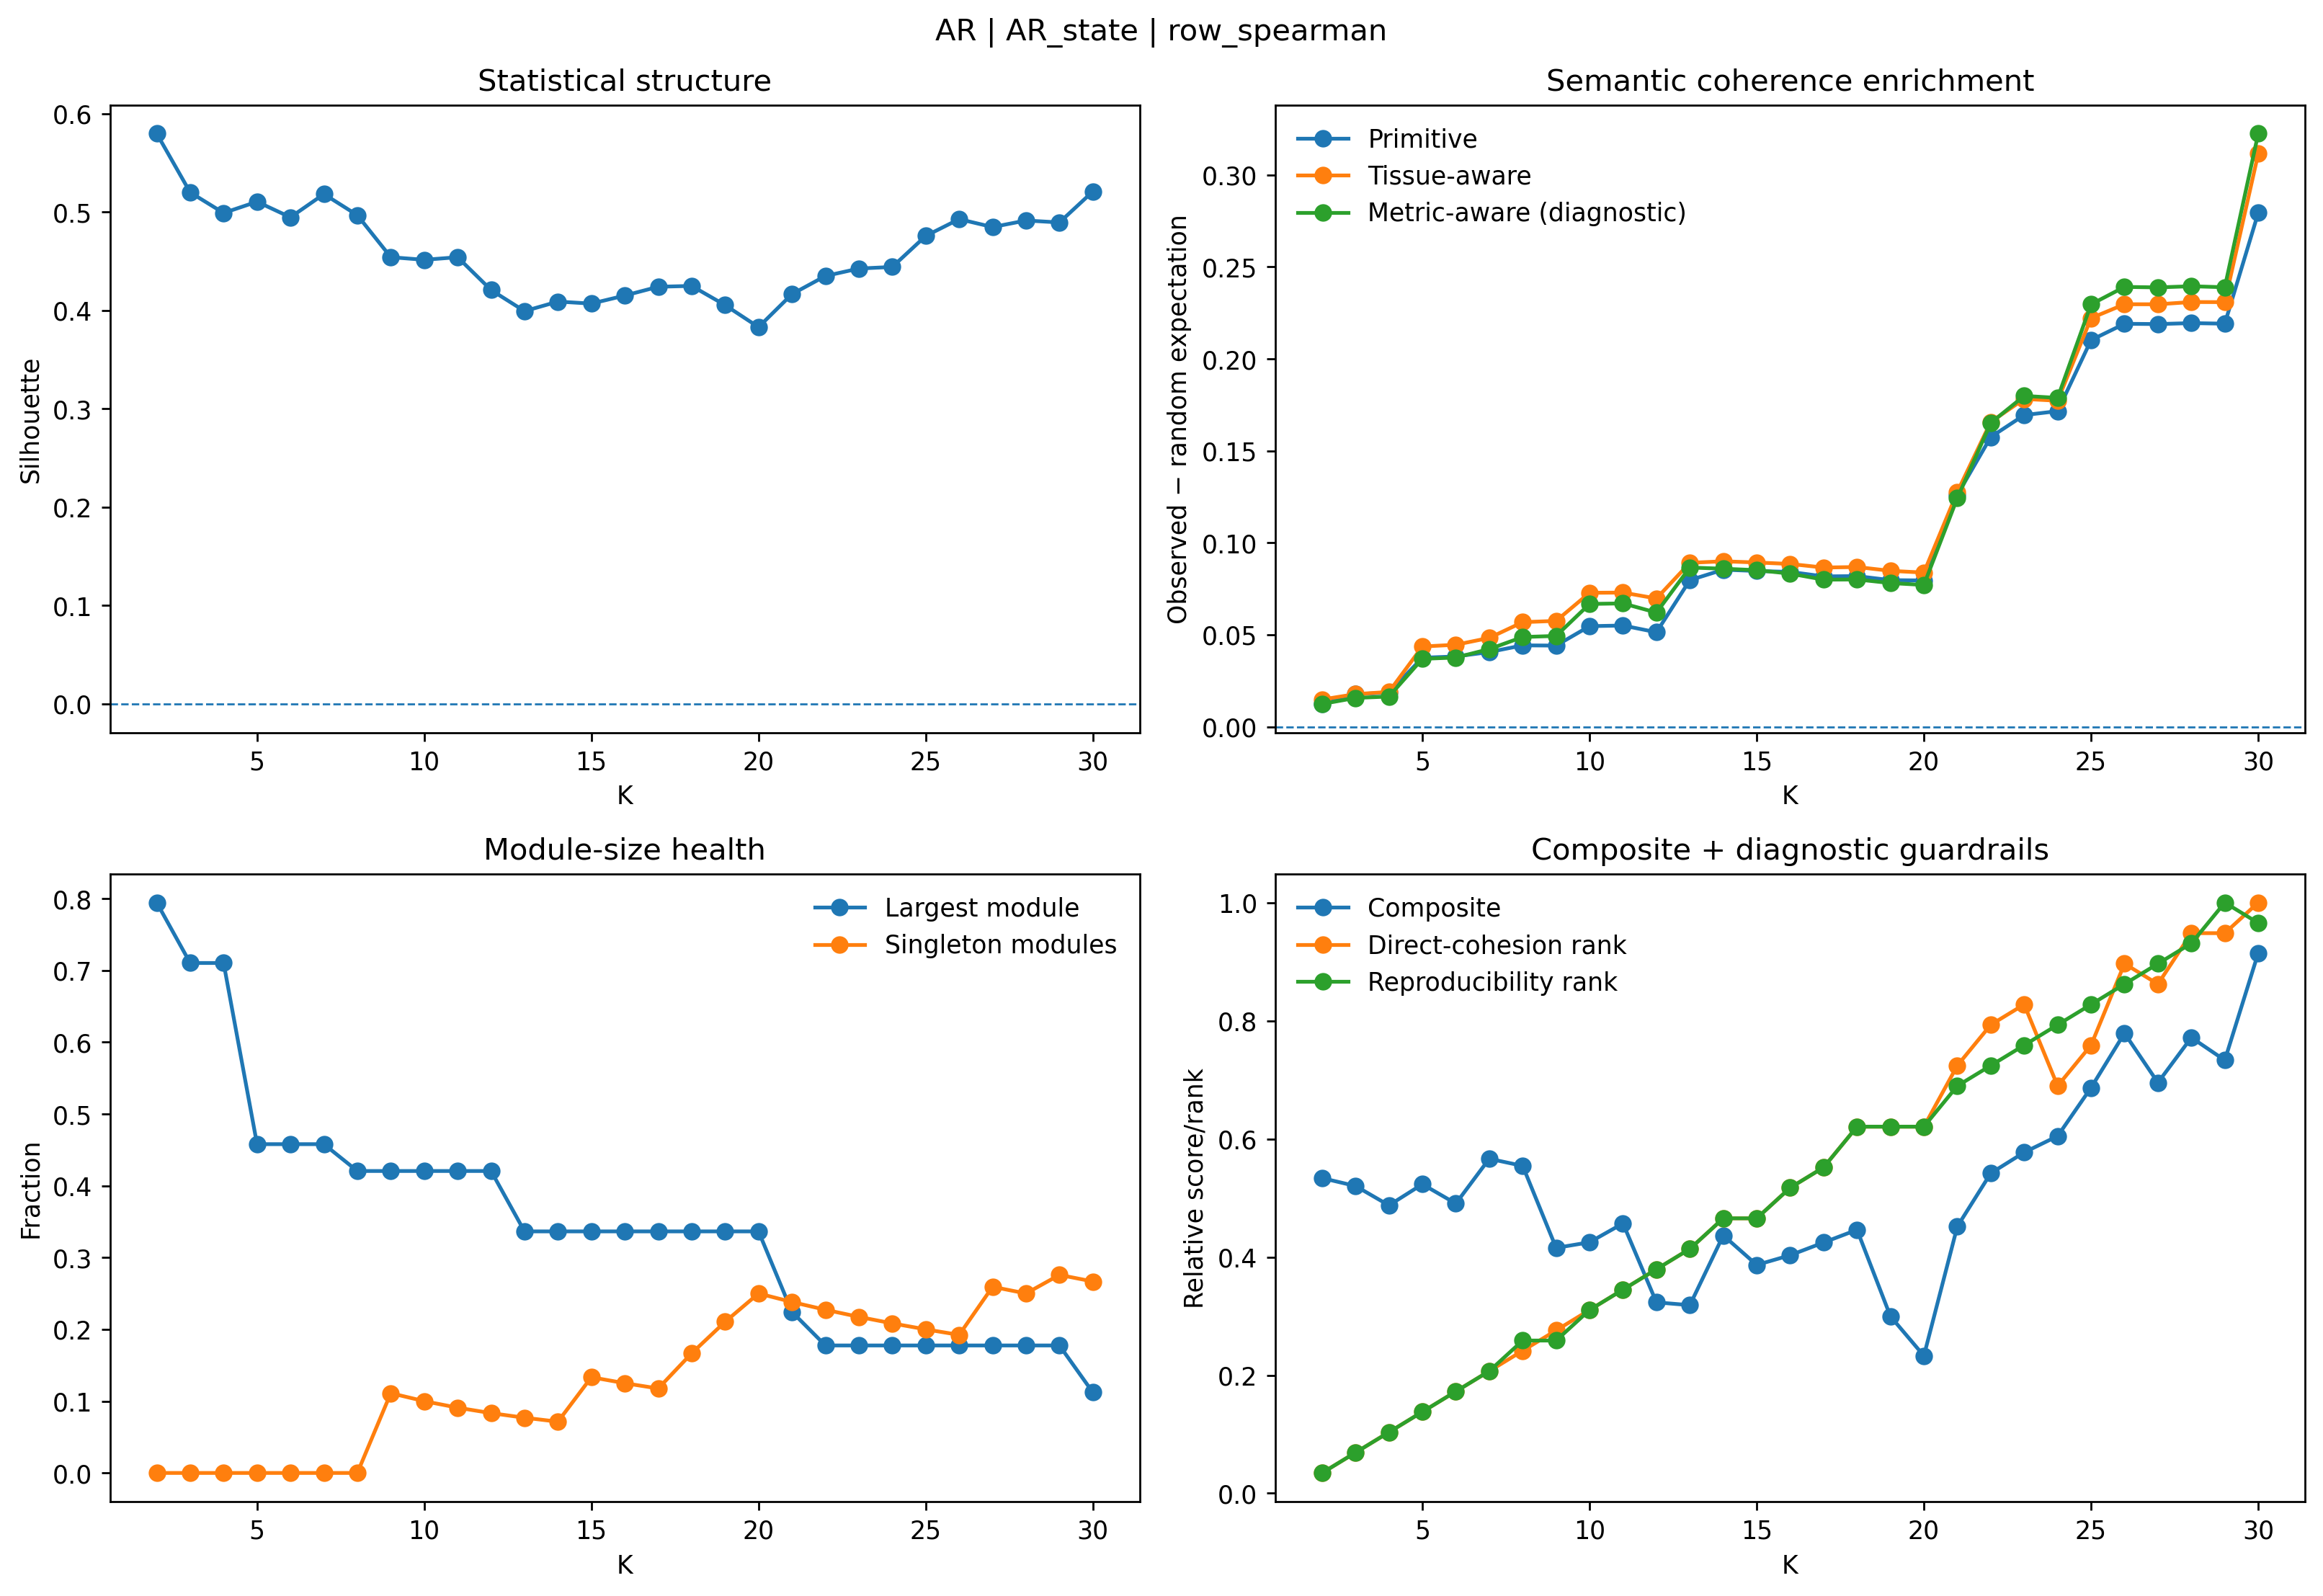


 01_statistical_silhouette.png


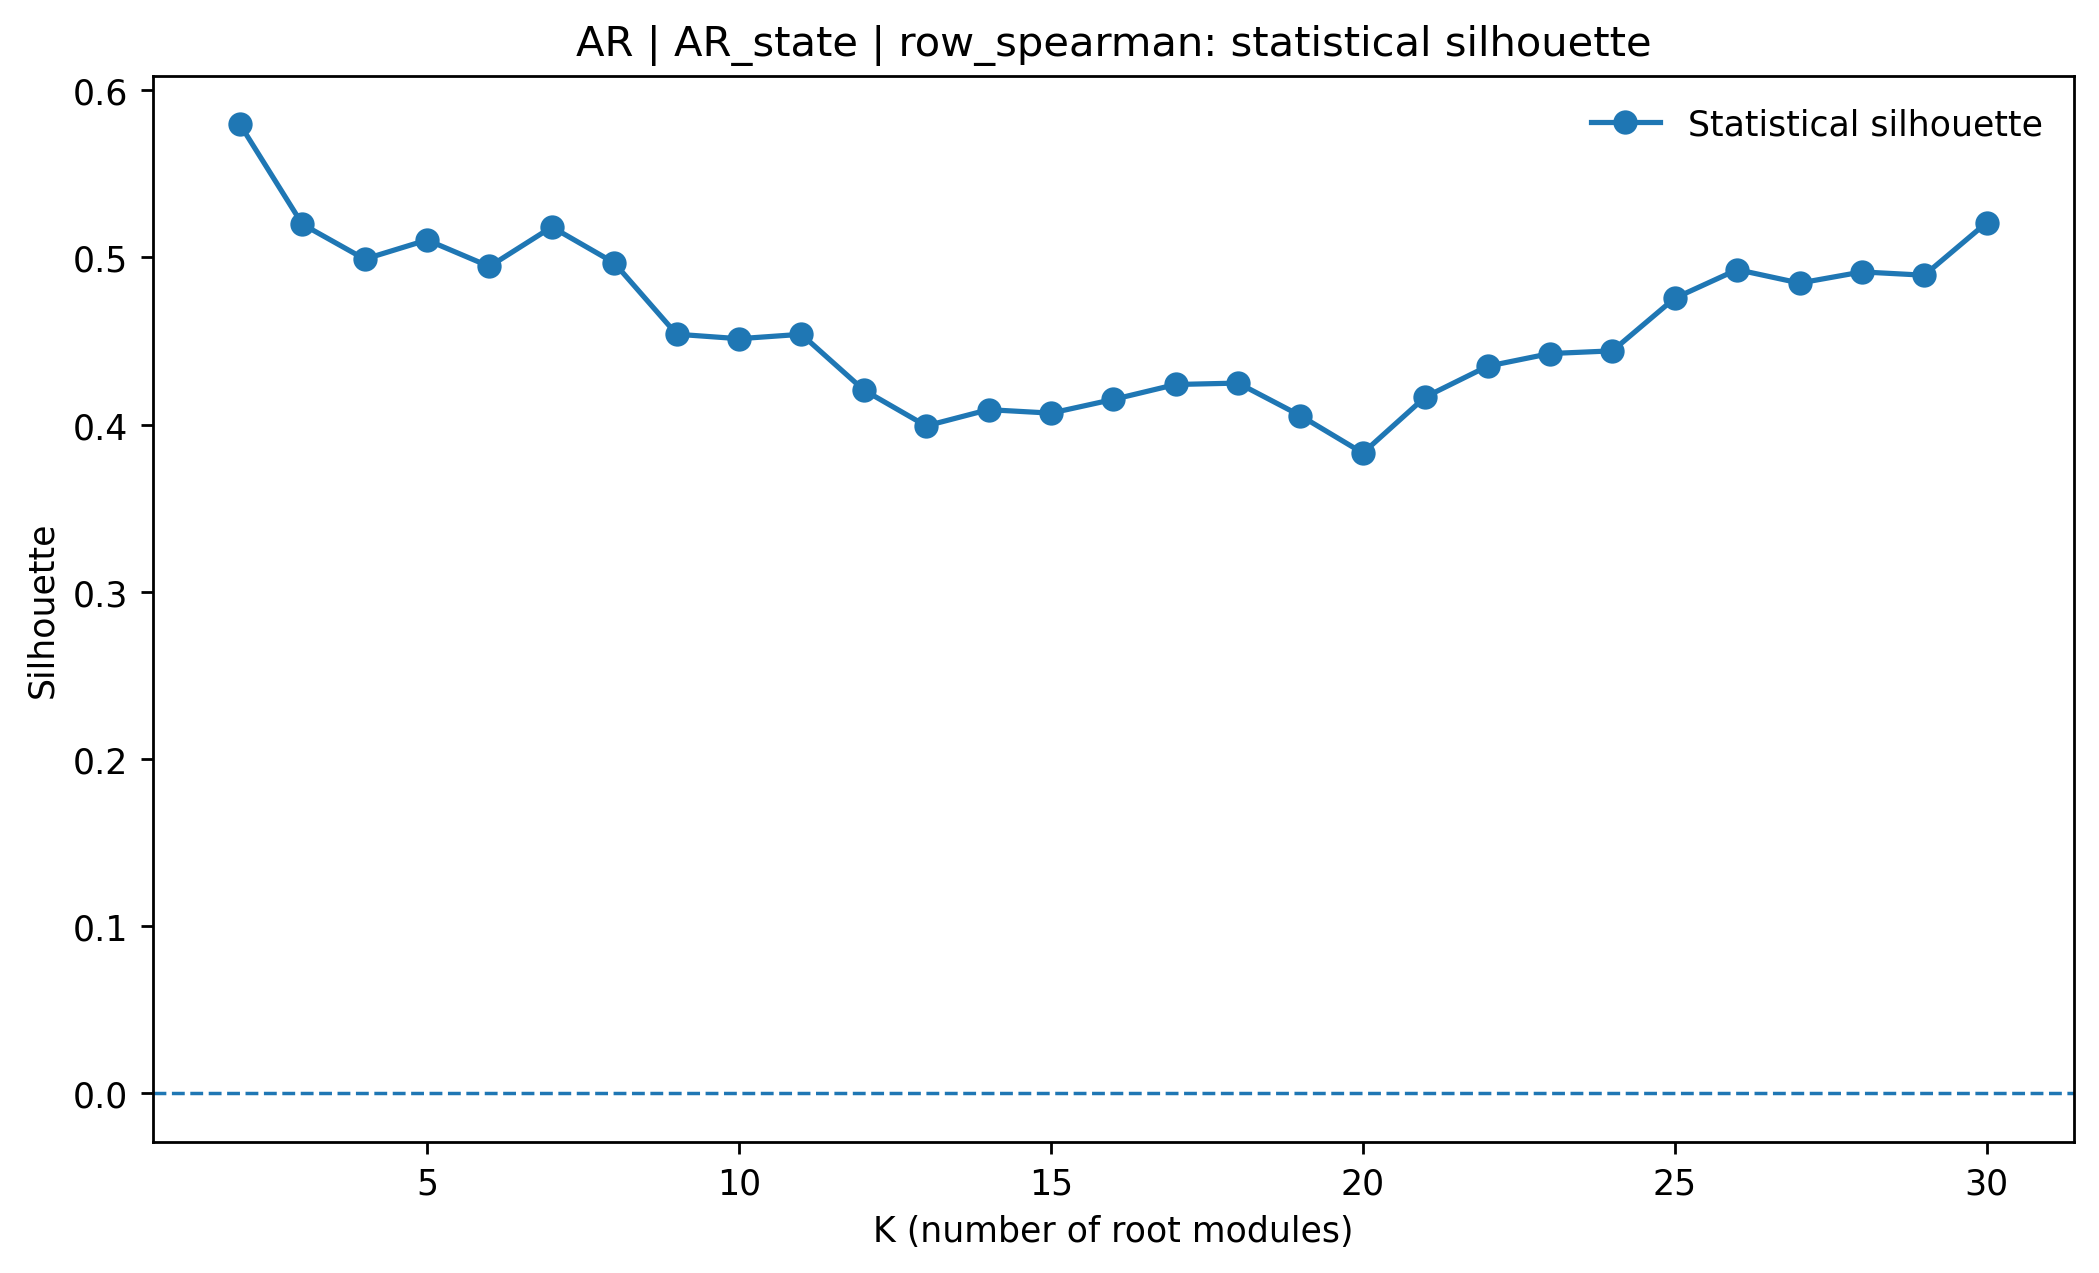


 02_semantic_silhouette.png


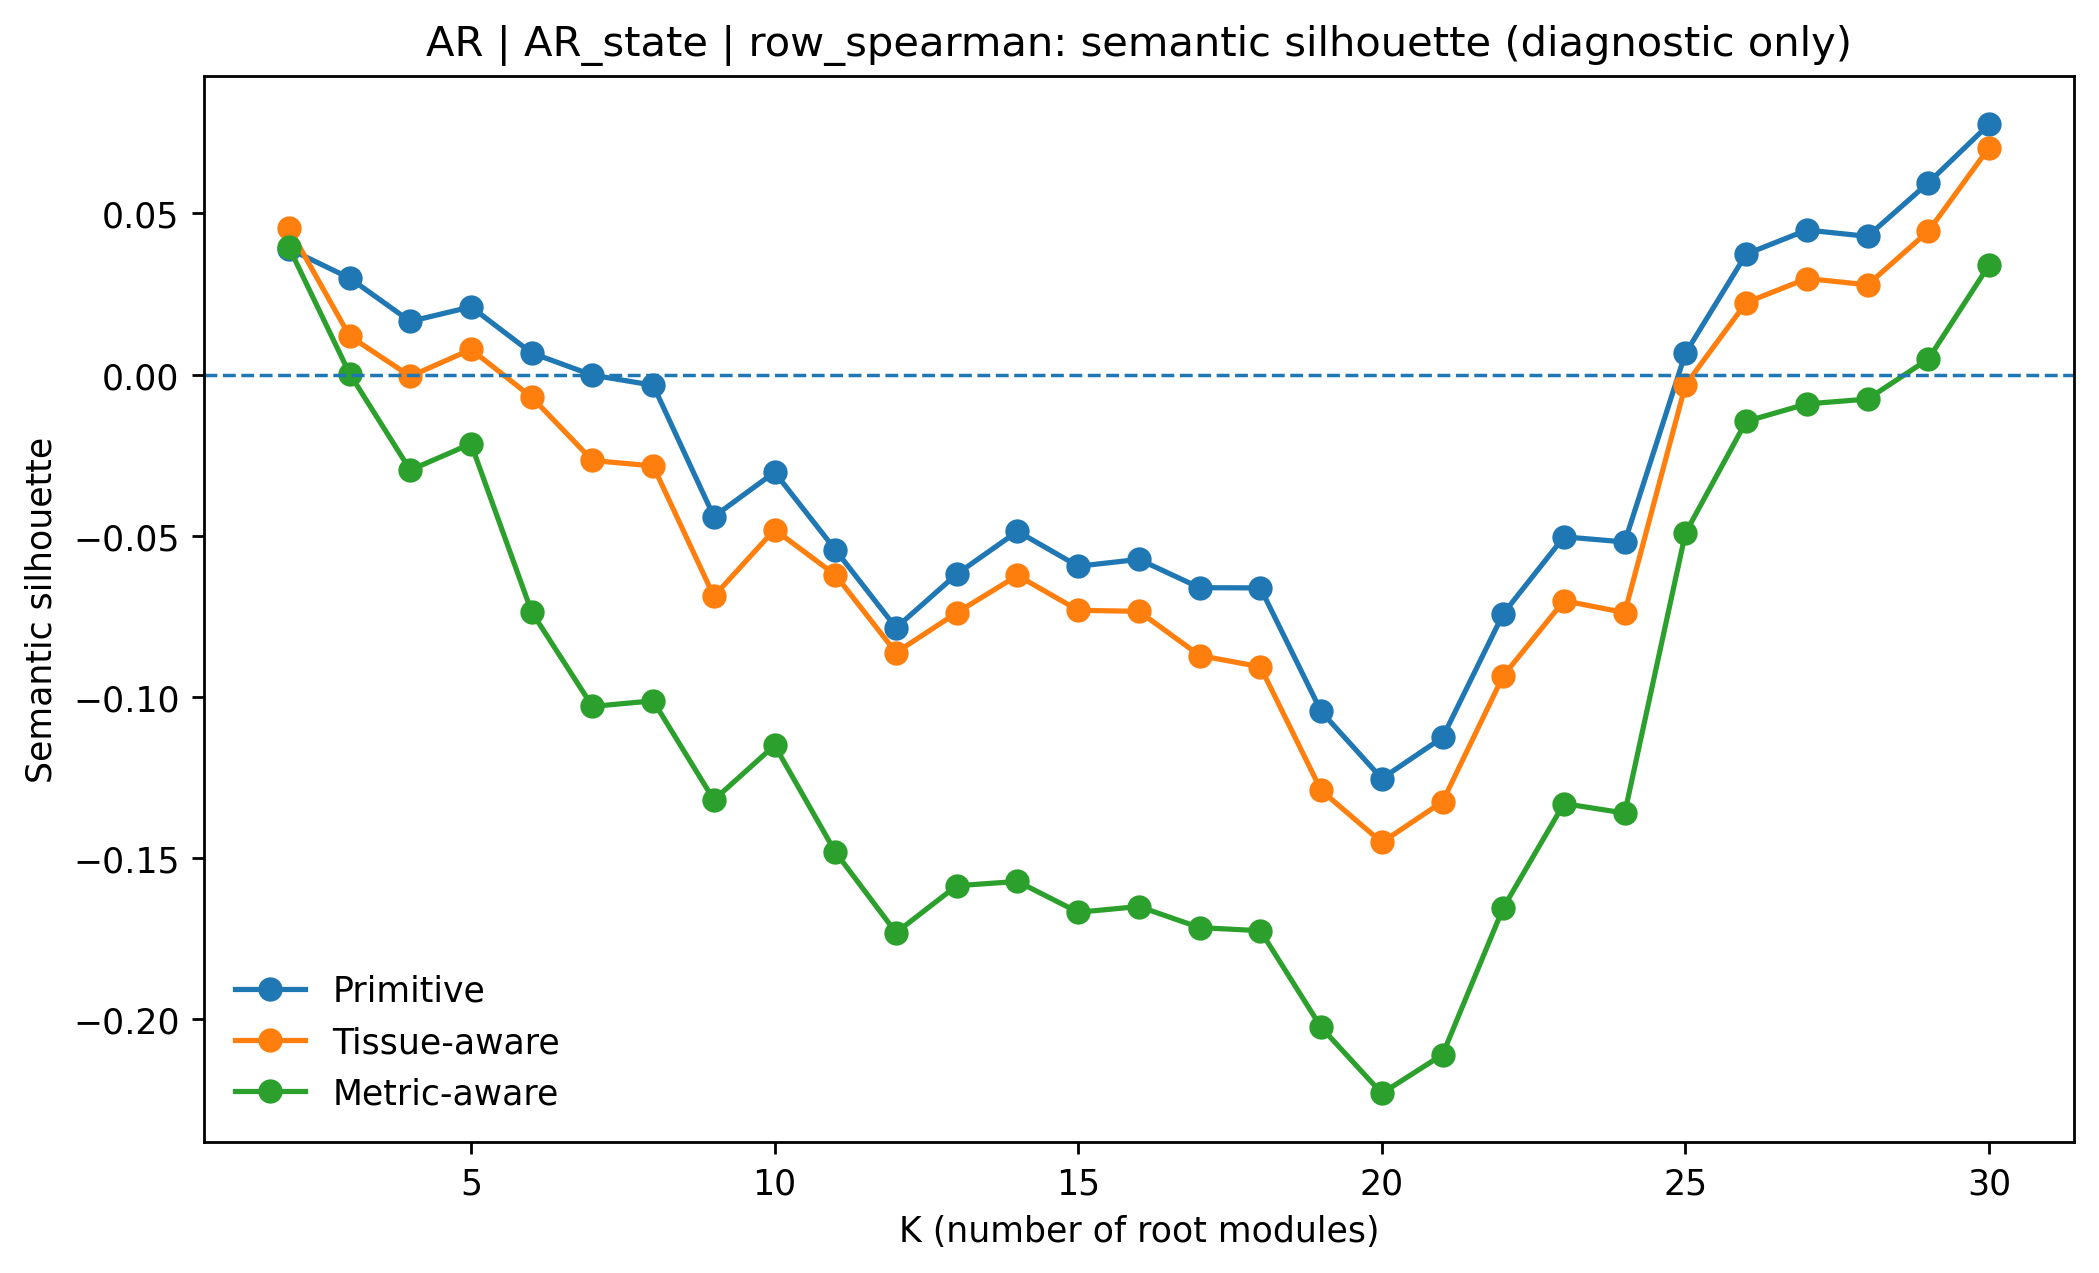


 03_semantic_coherence_raw_vs_null.png


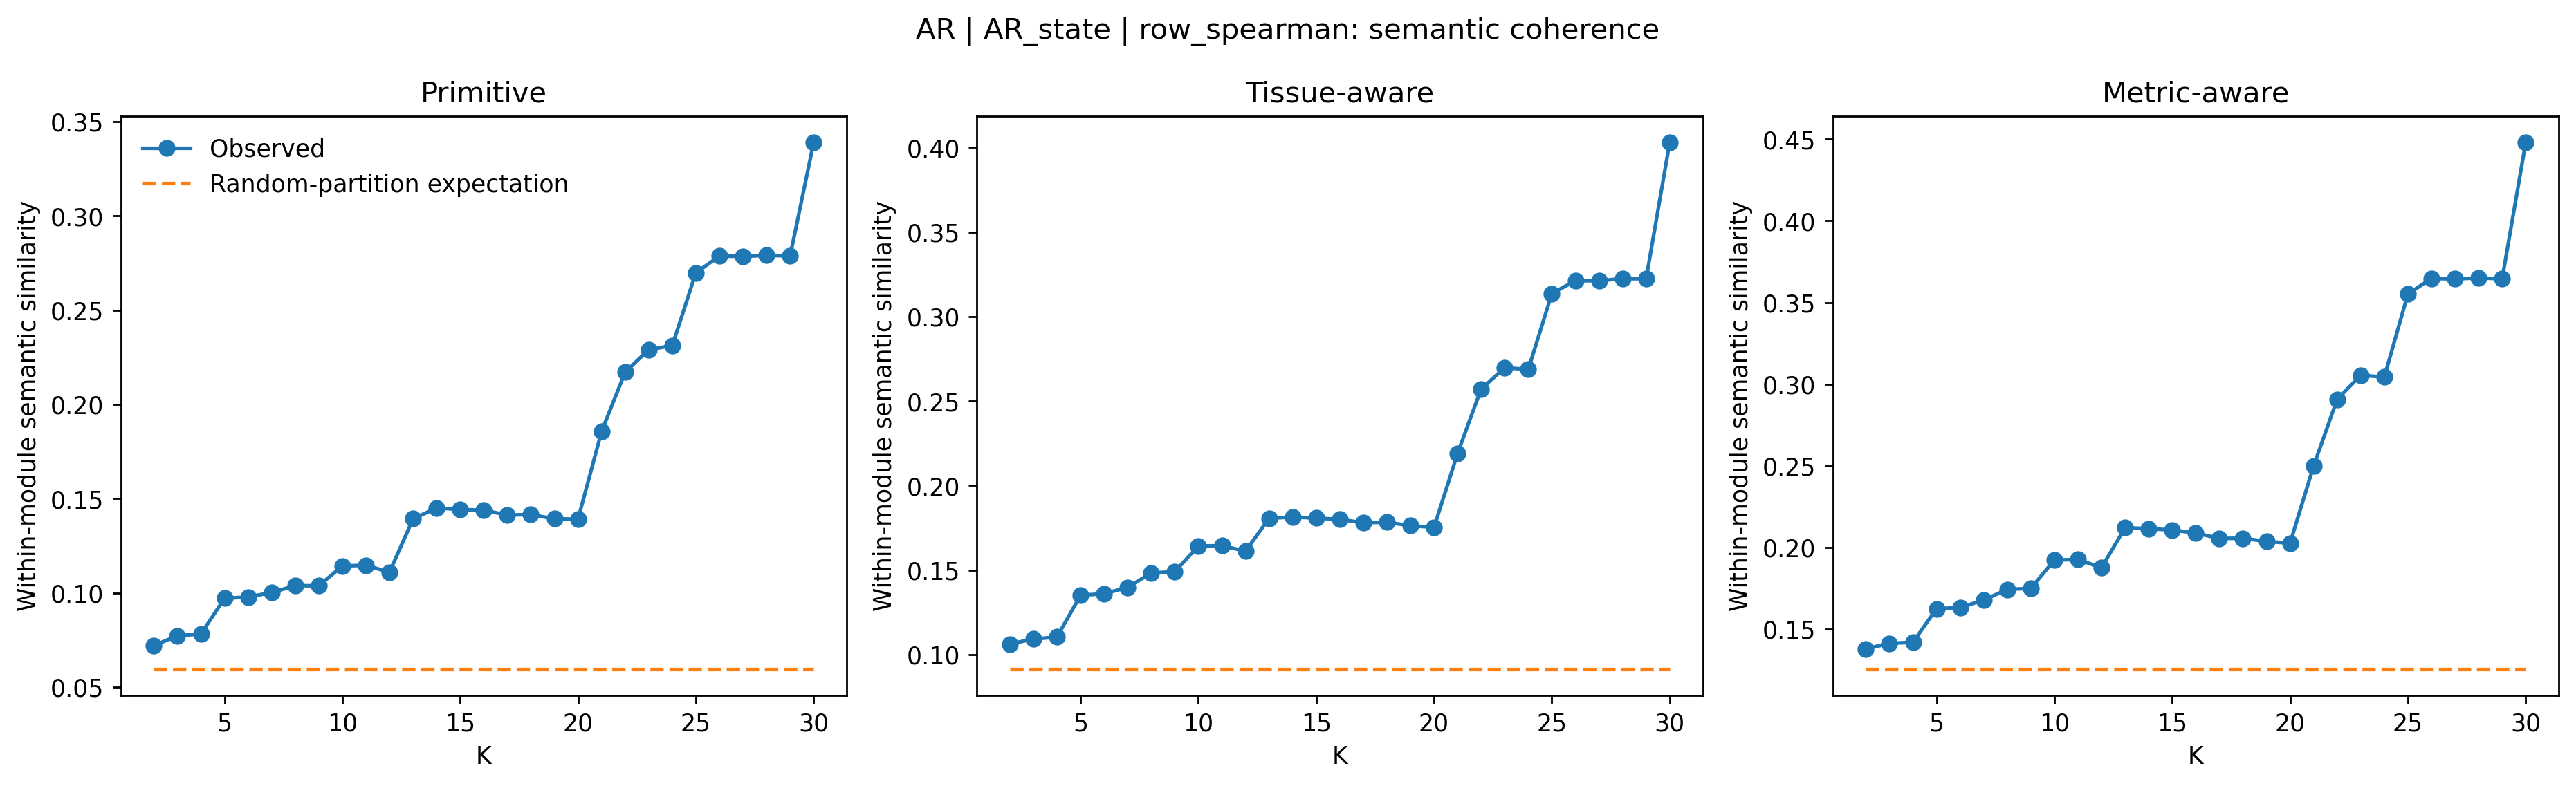


 04_semantic_coherence_enrichment.png


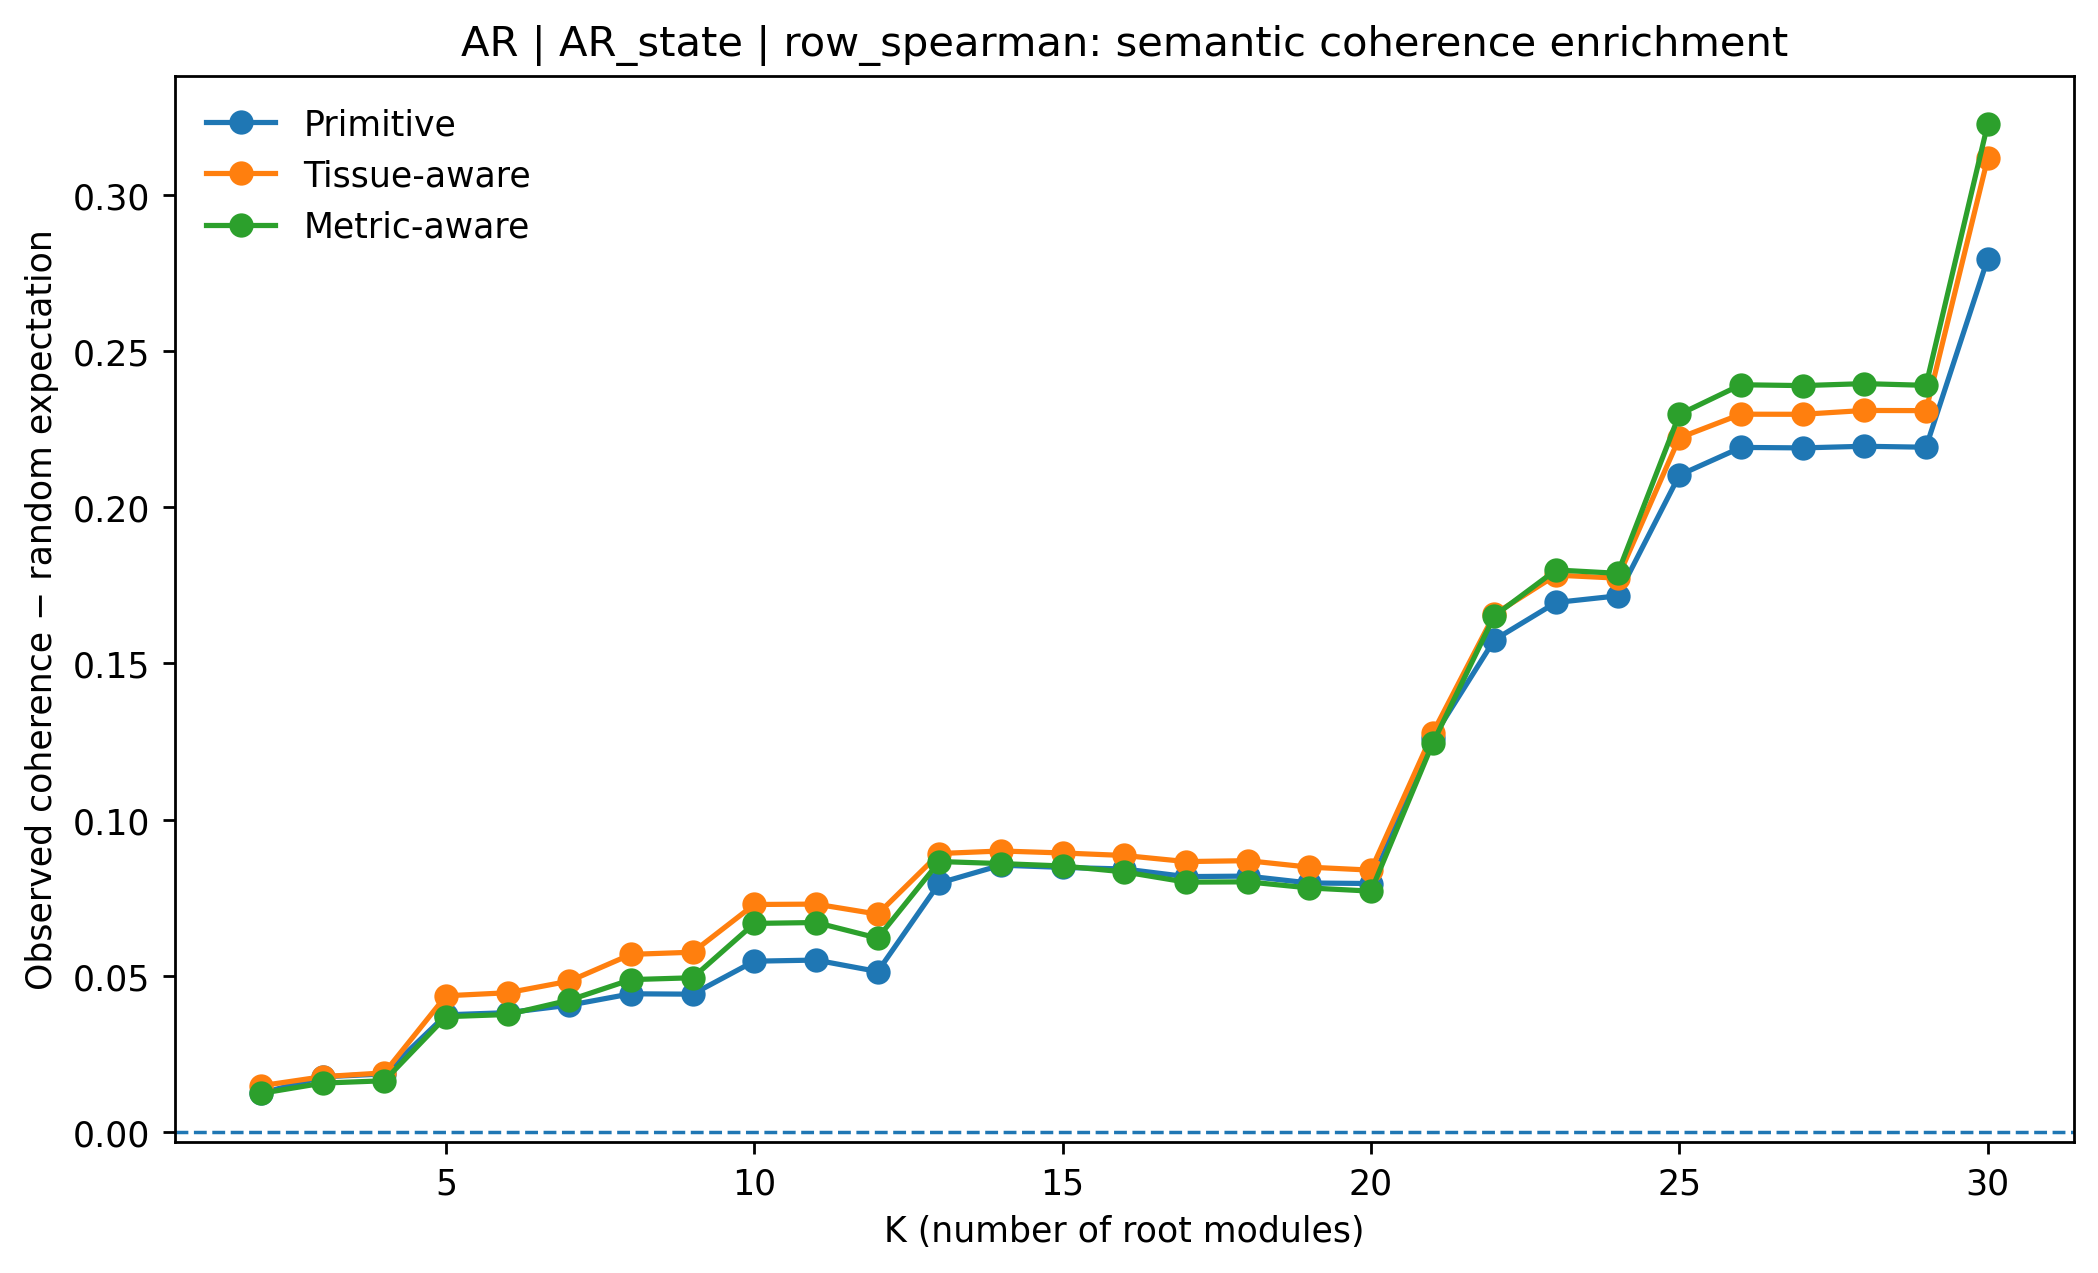


 06_module_size_health.png


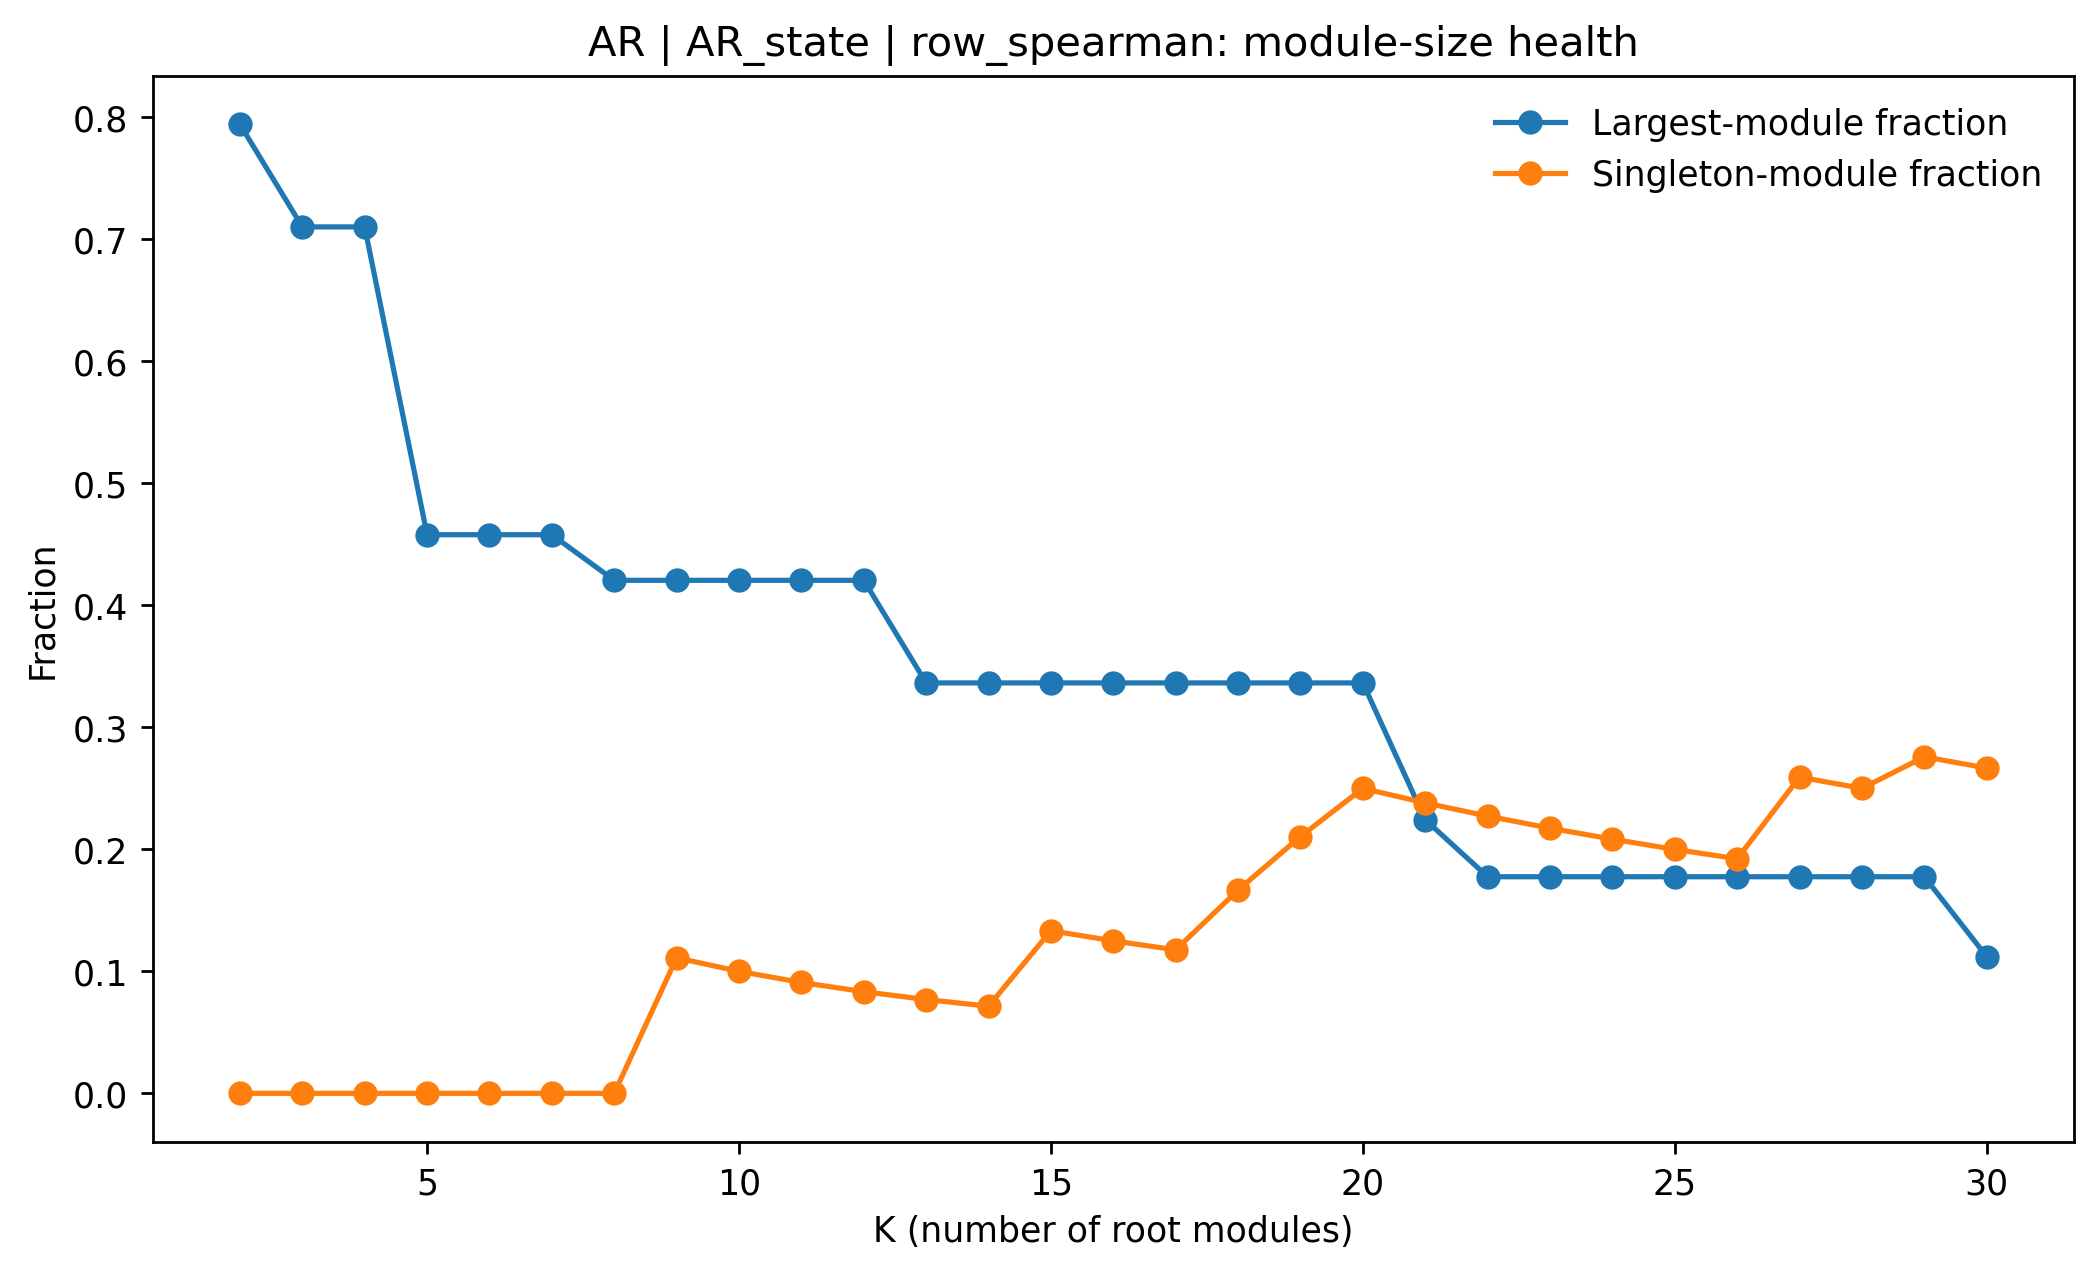


 07_within_module_consensus_rho.png


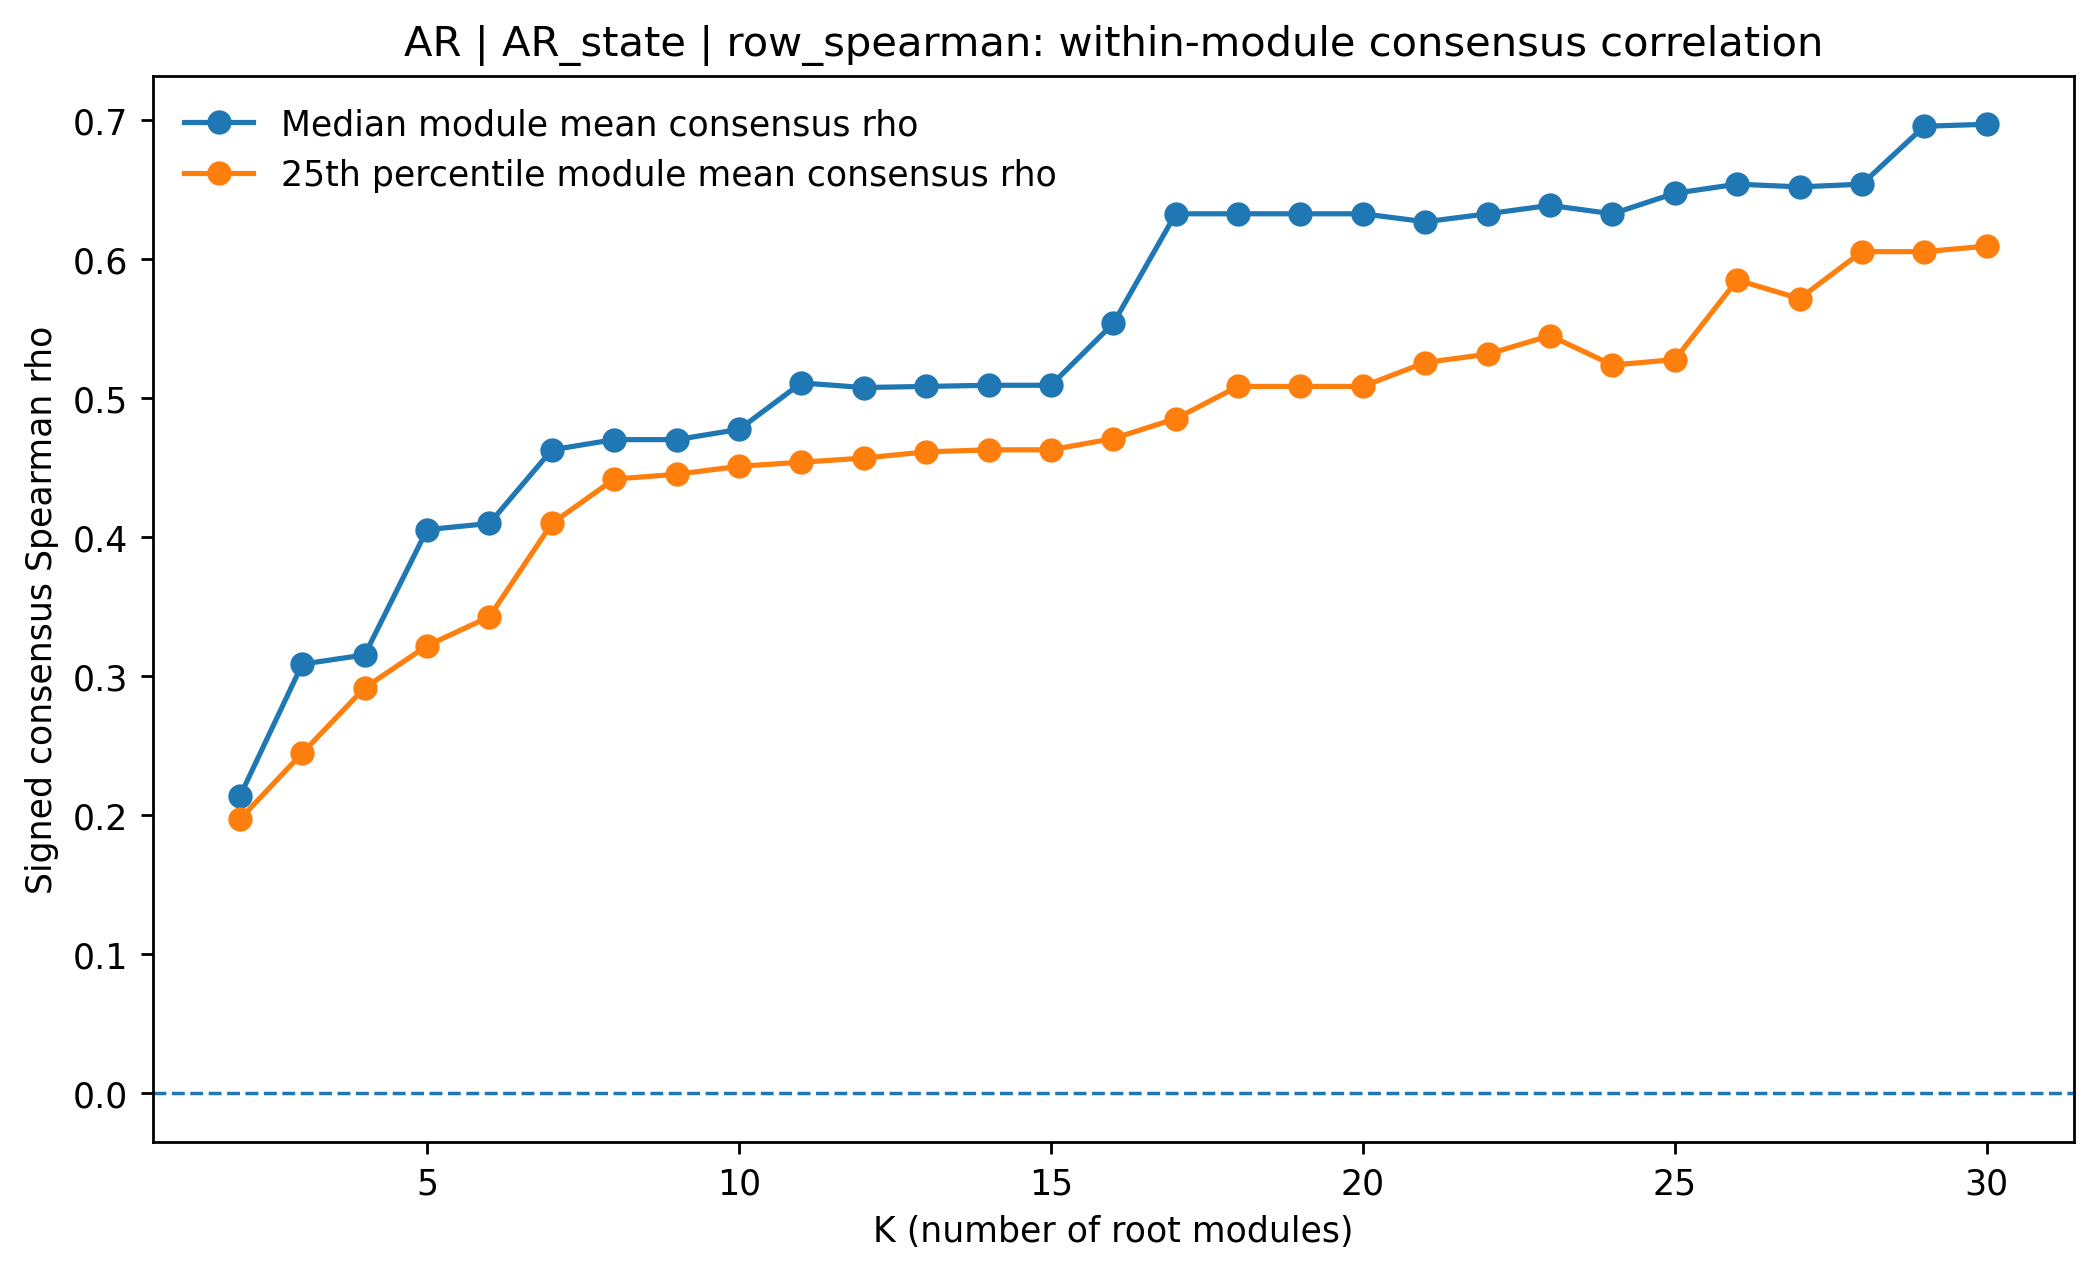


 08_cross_cohort_reproducibility.png


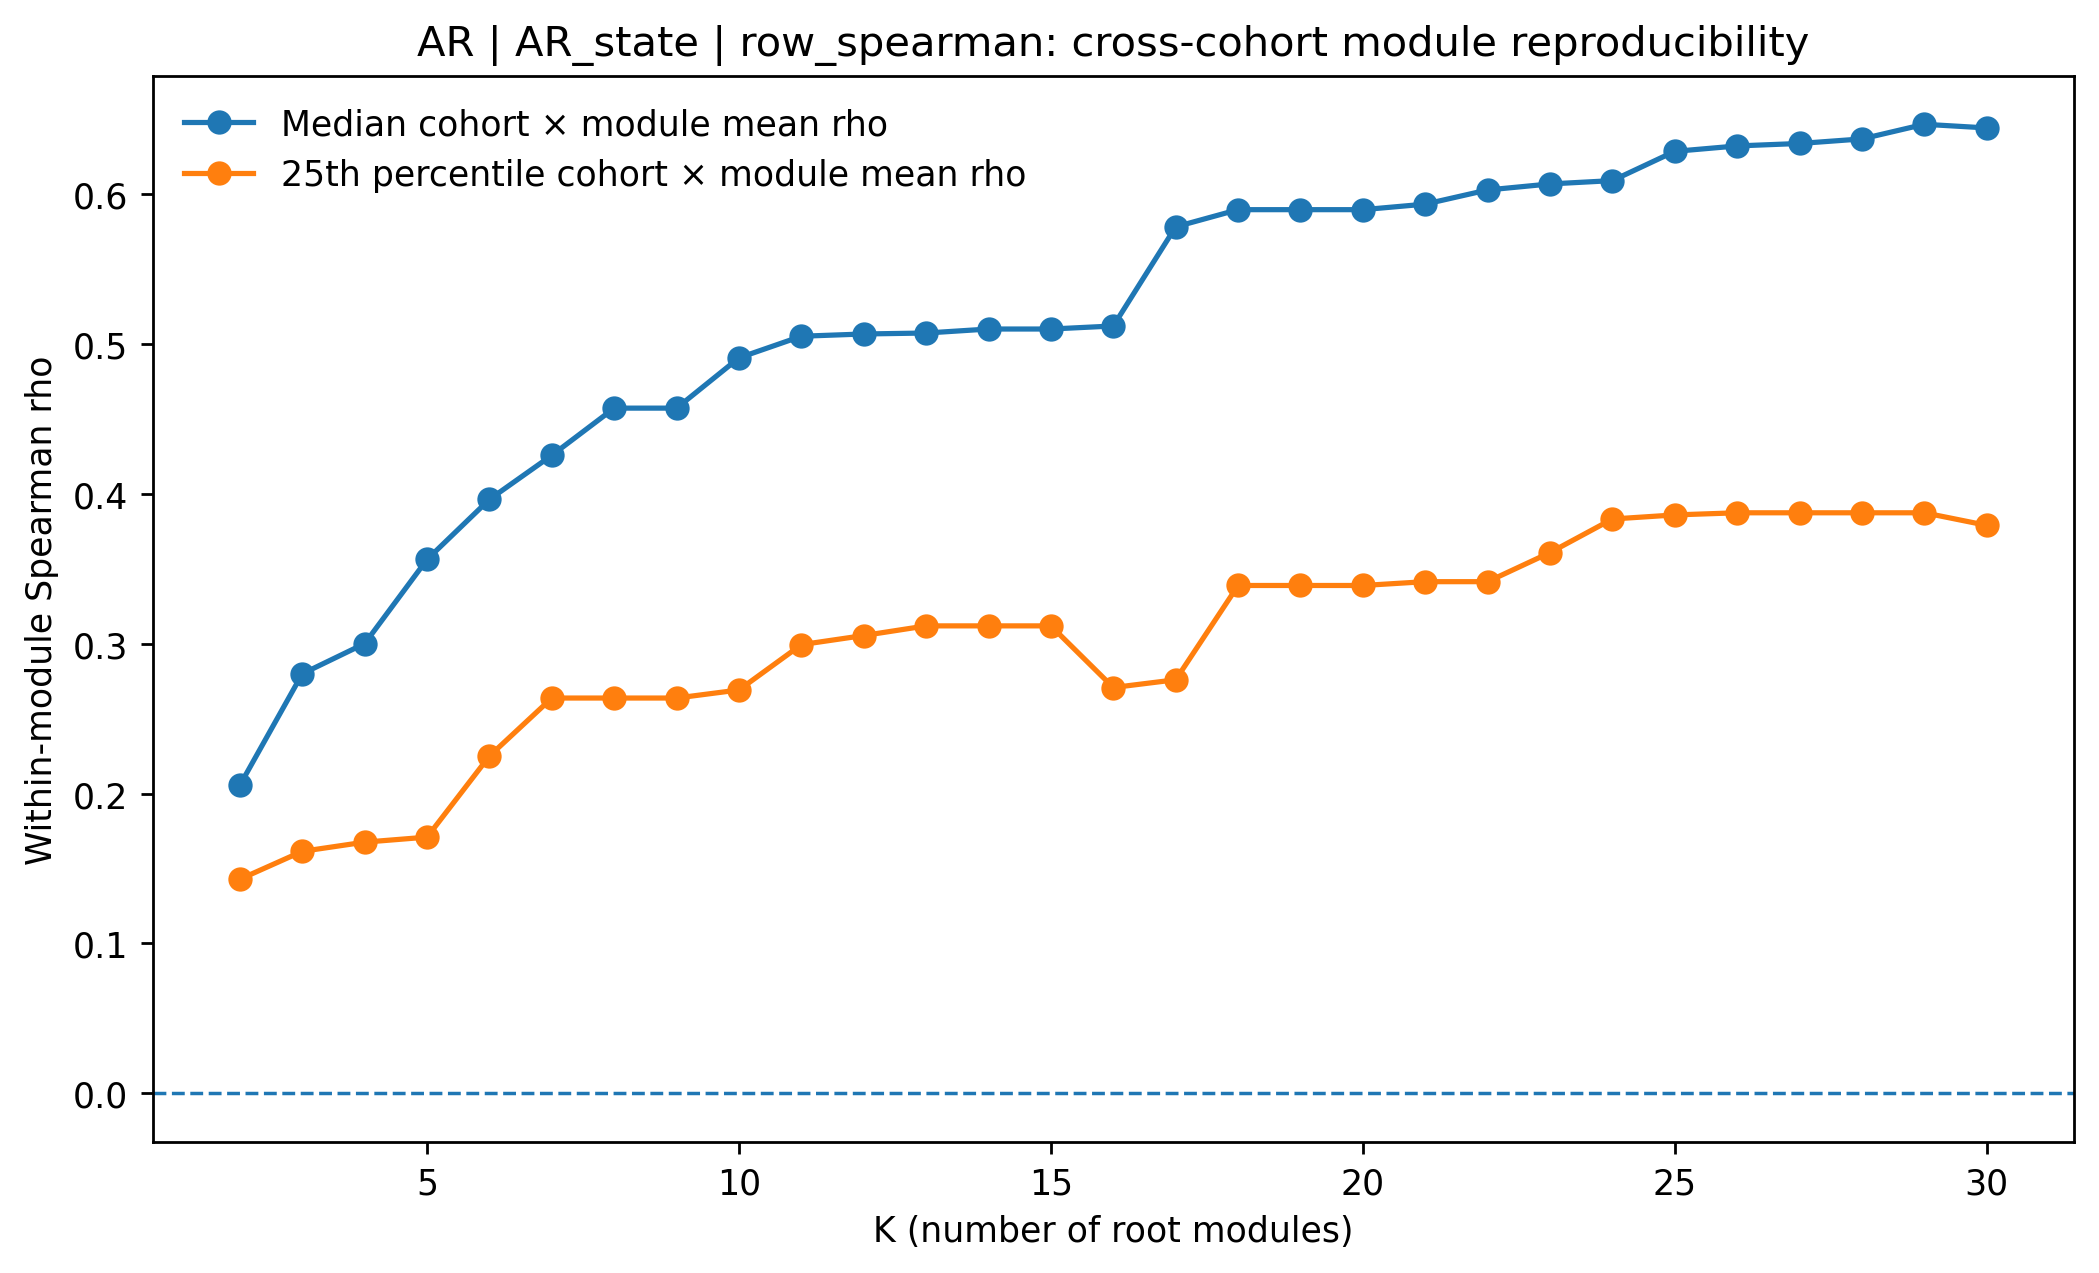


 09_k_composite_score.png


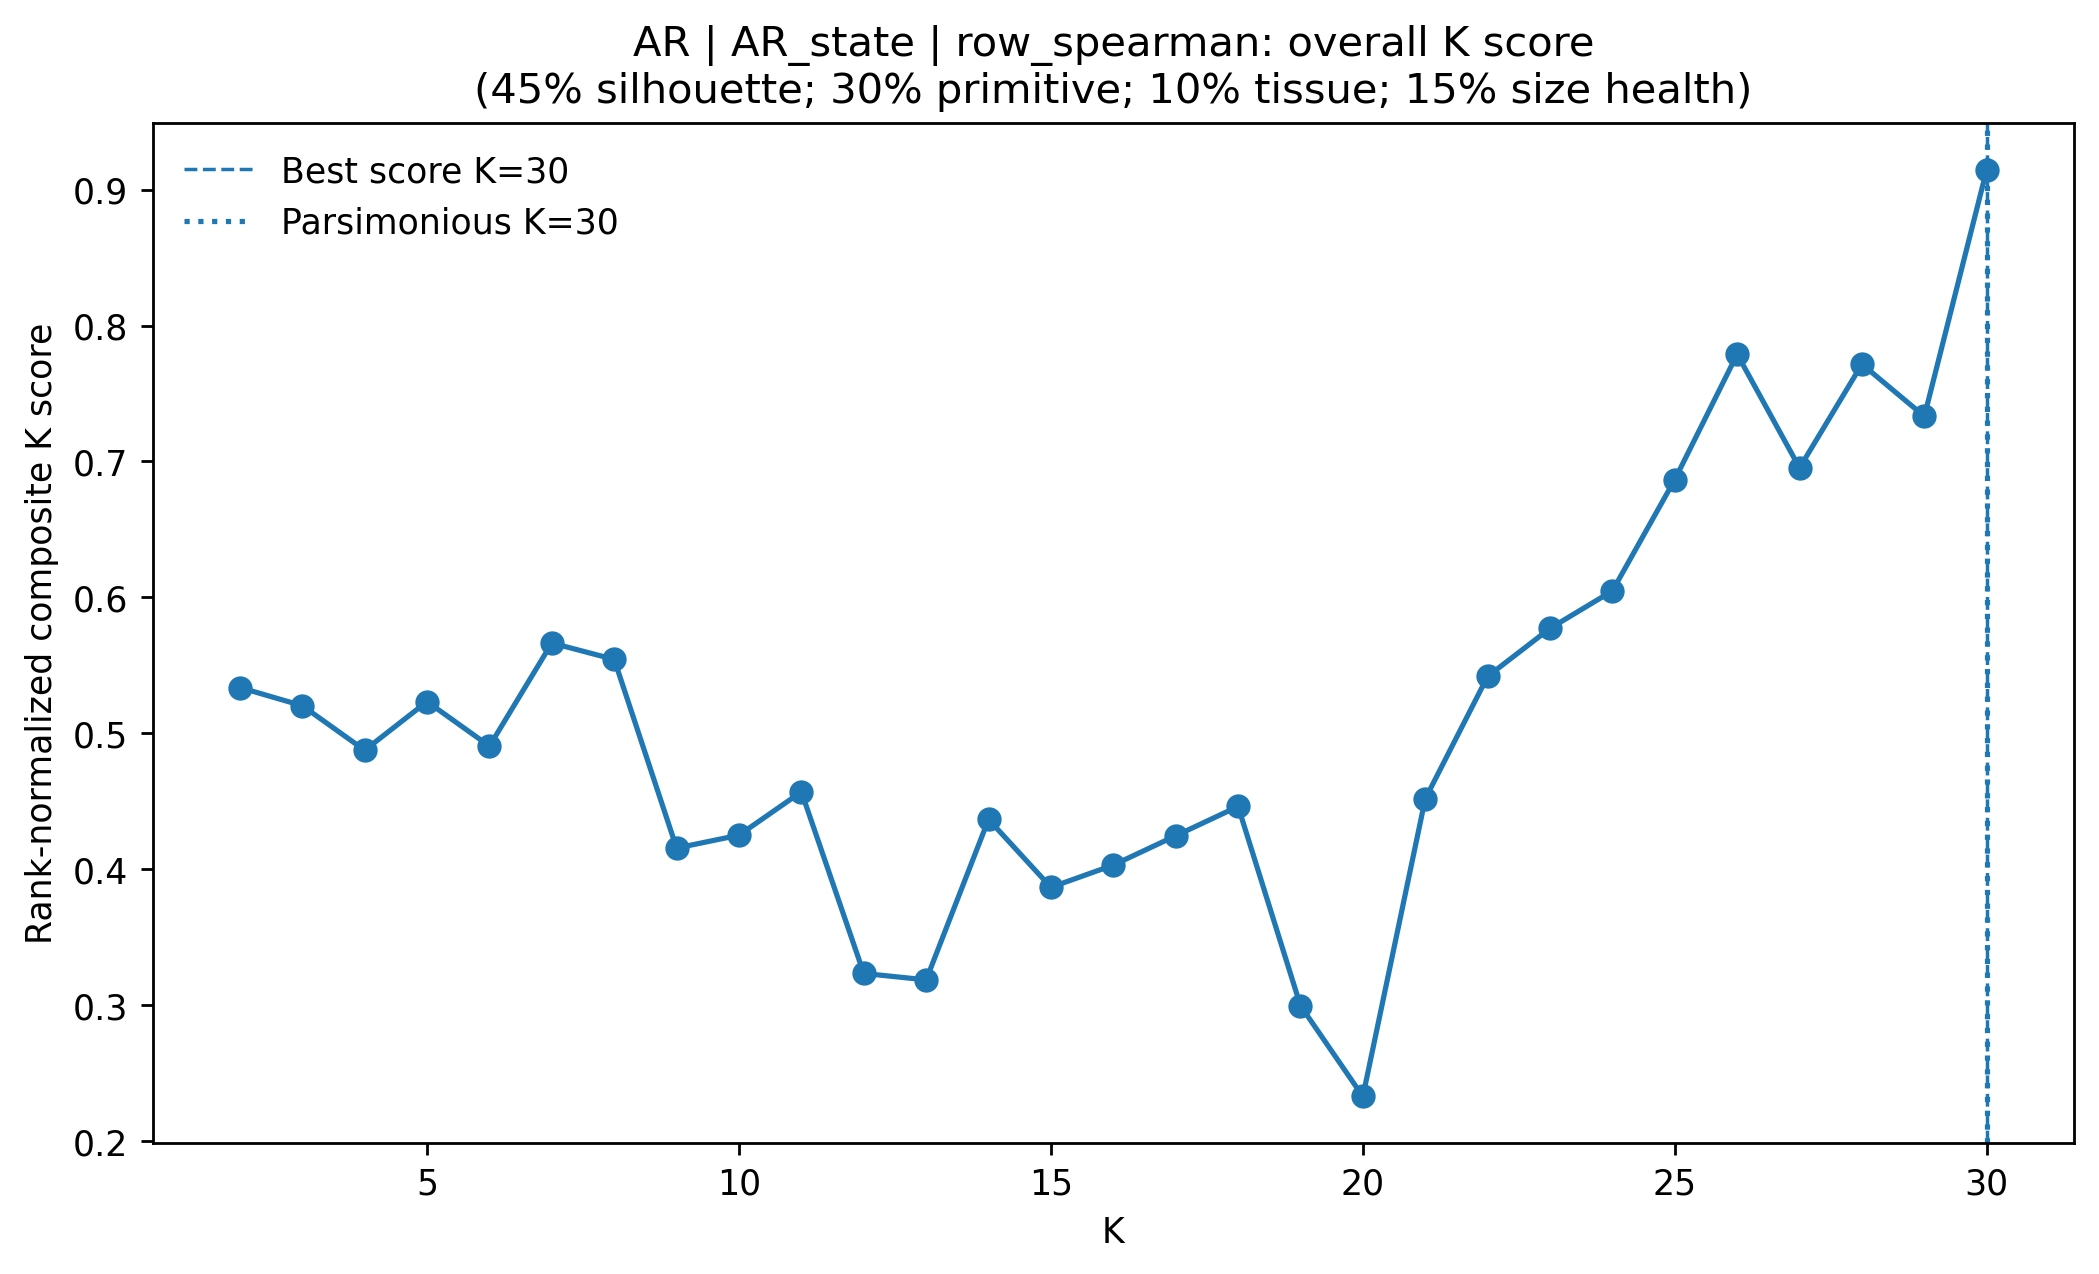


Top candidate-K heatmaps:
K26_consensus_heatmap.png


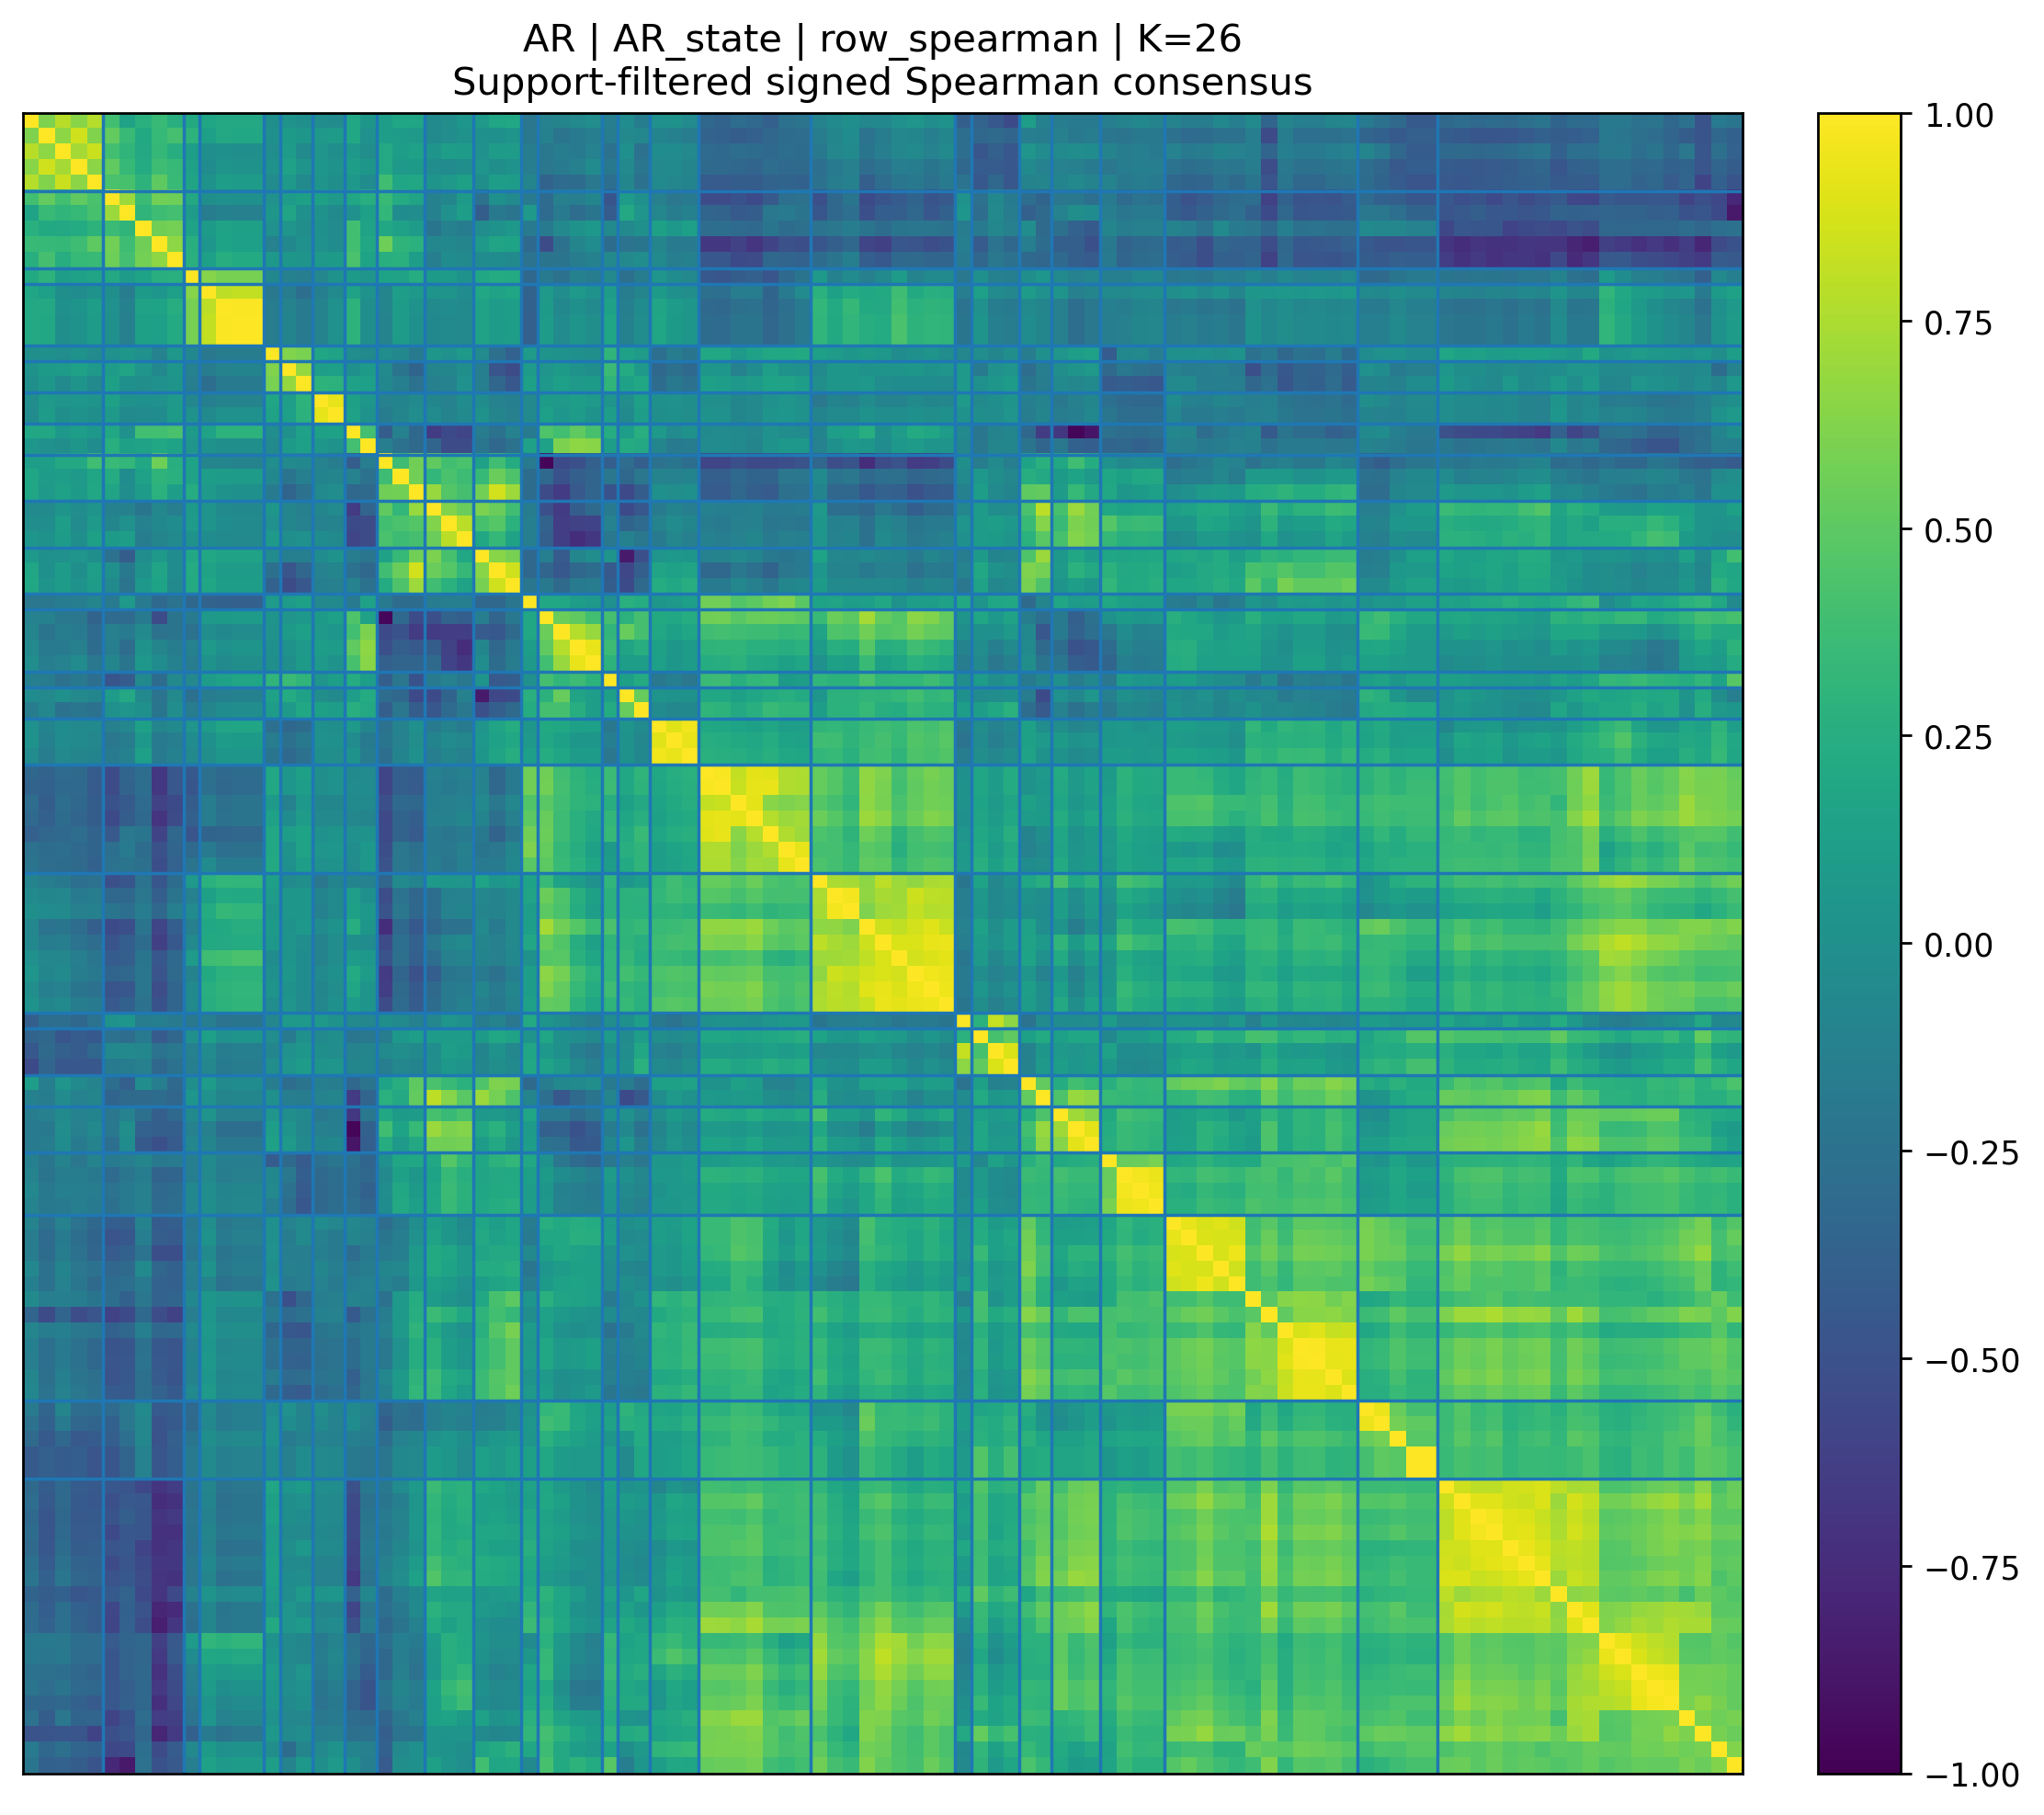

K28_consensus_heatmap.png


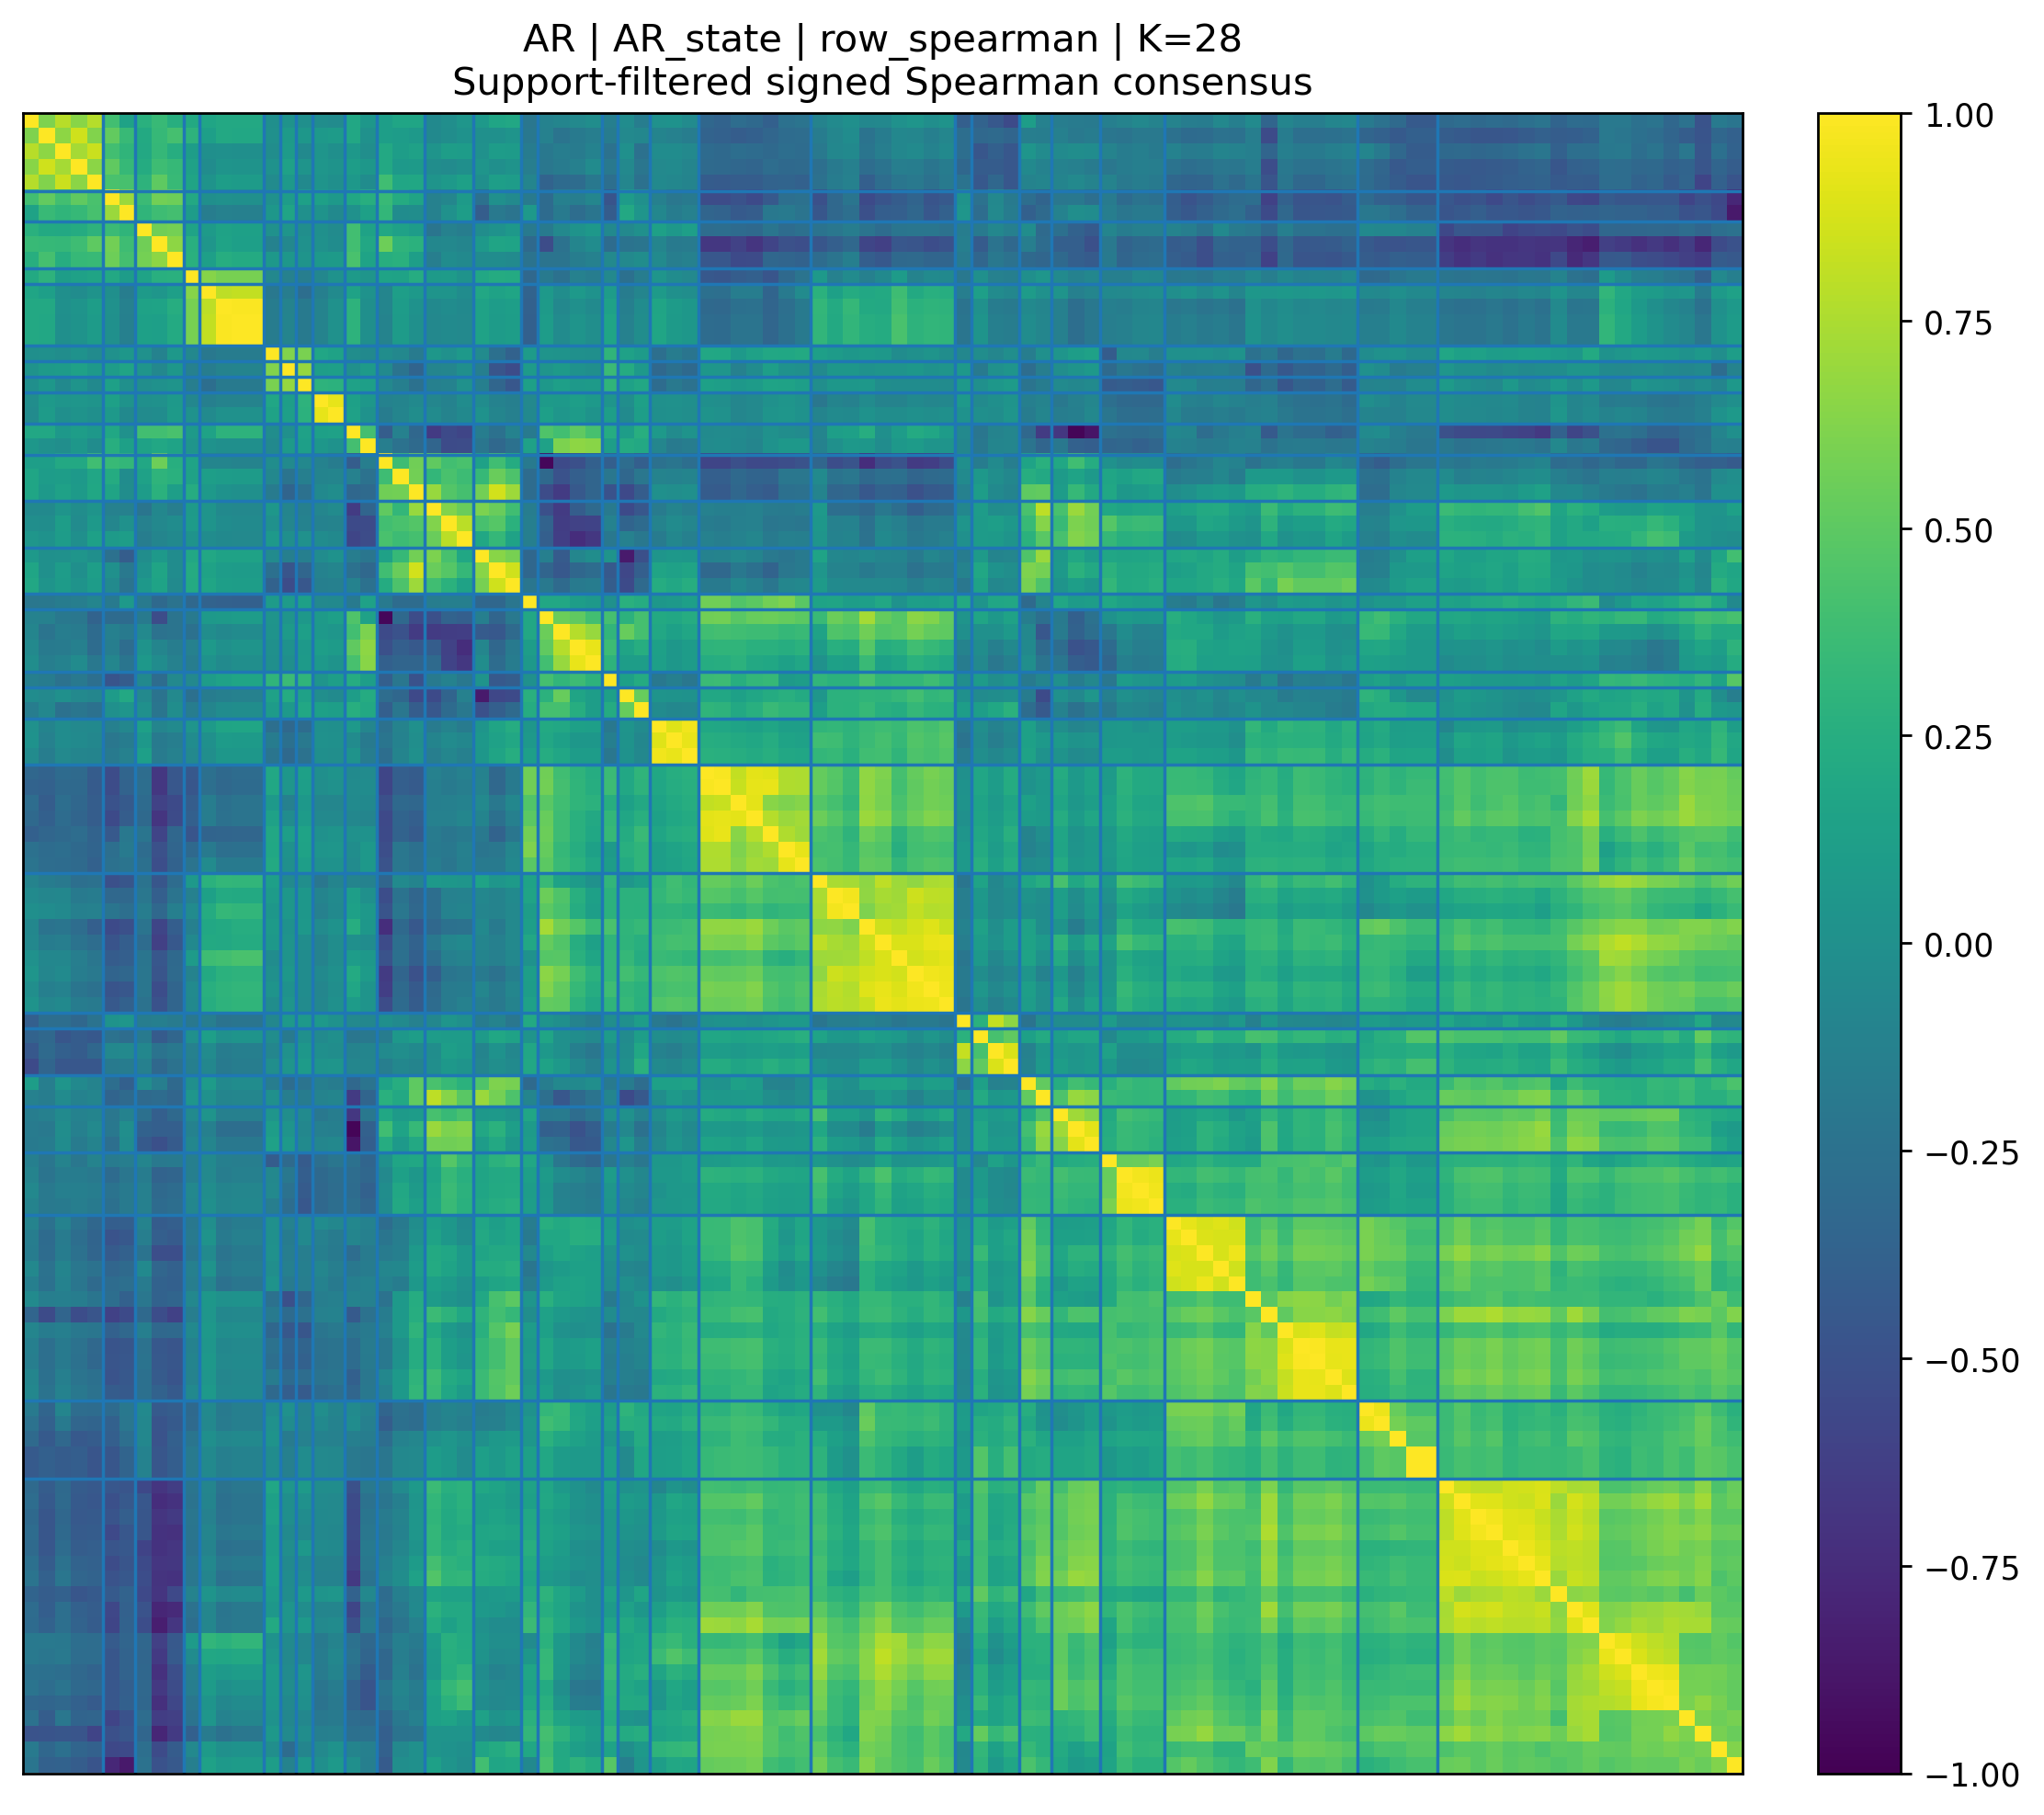

K30_consensus_heatmap.png


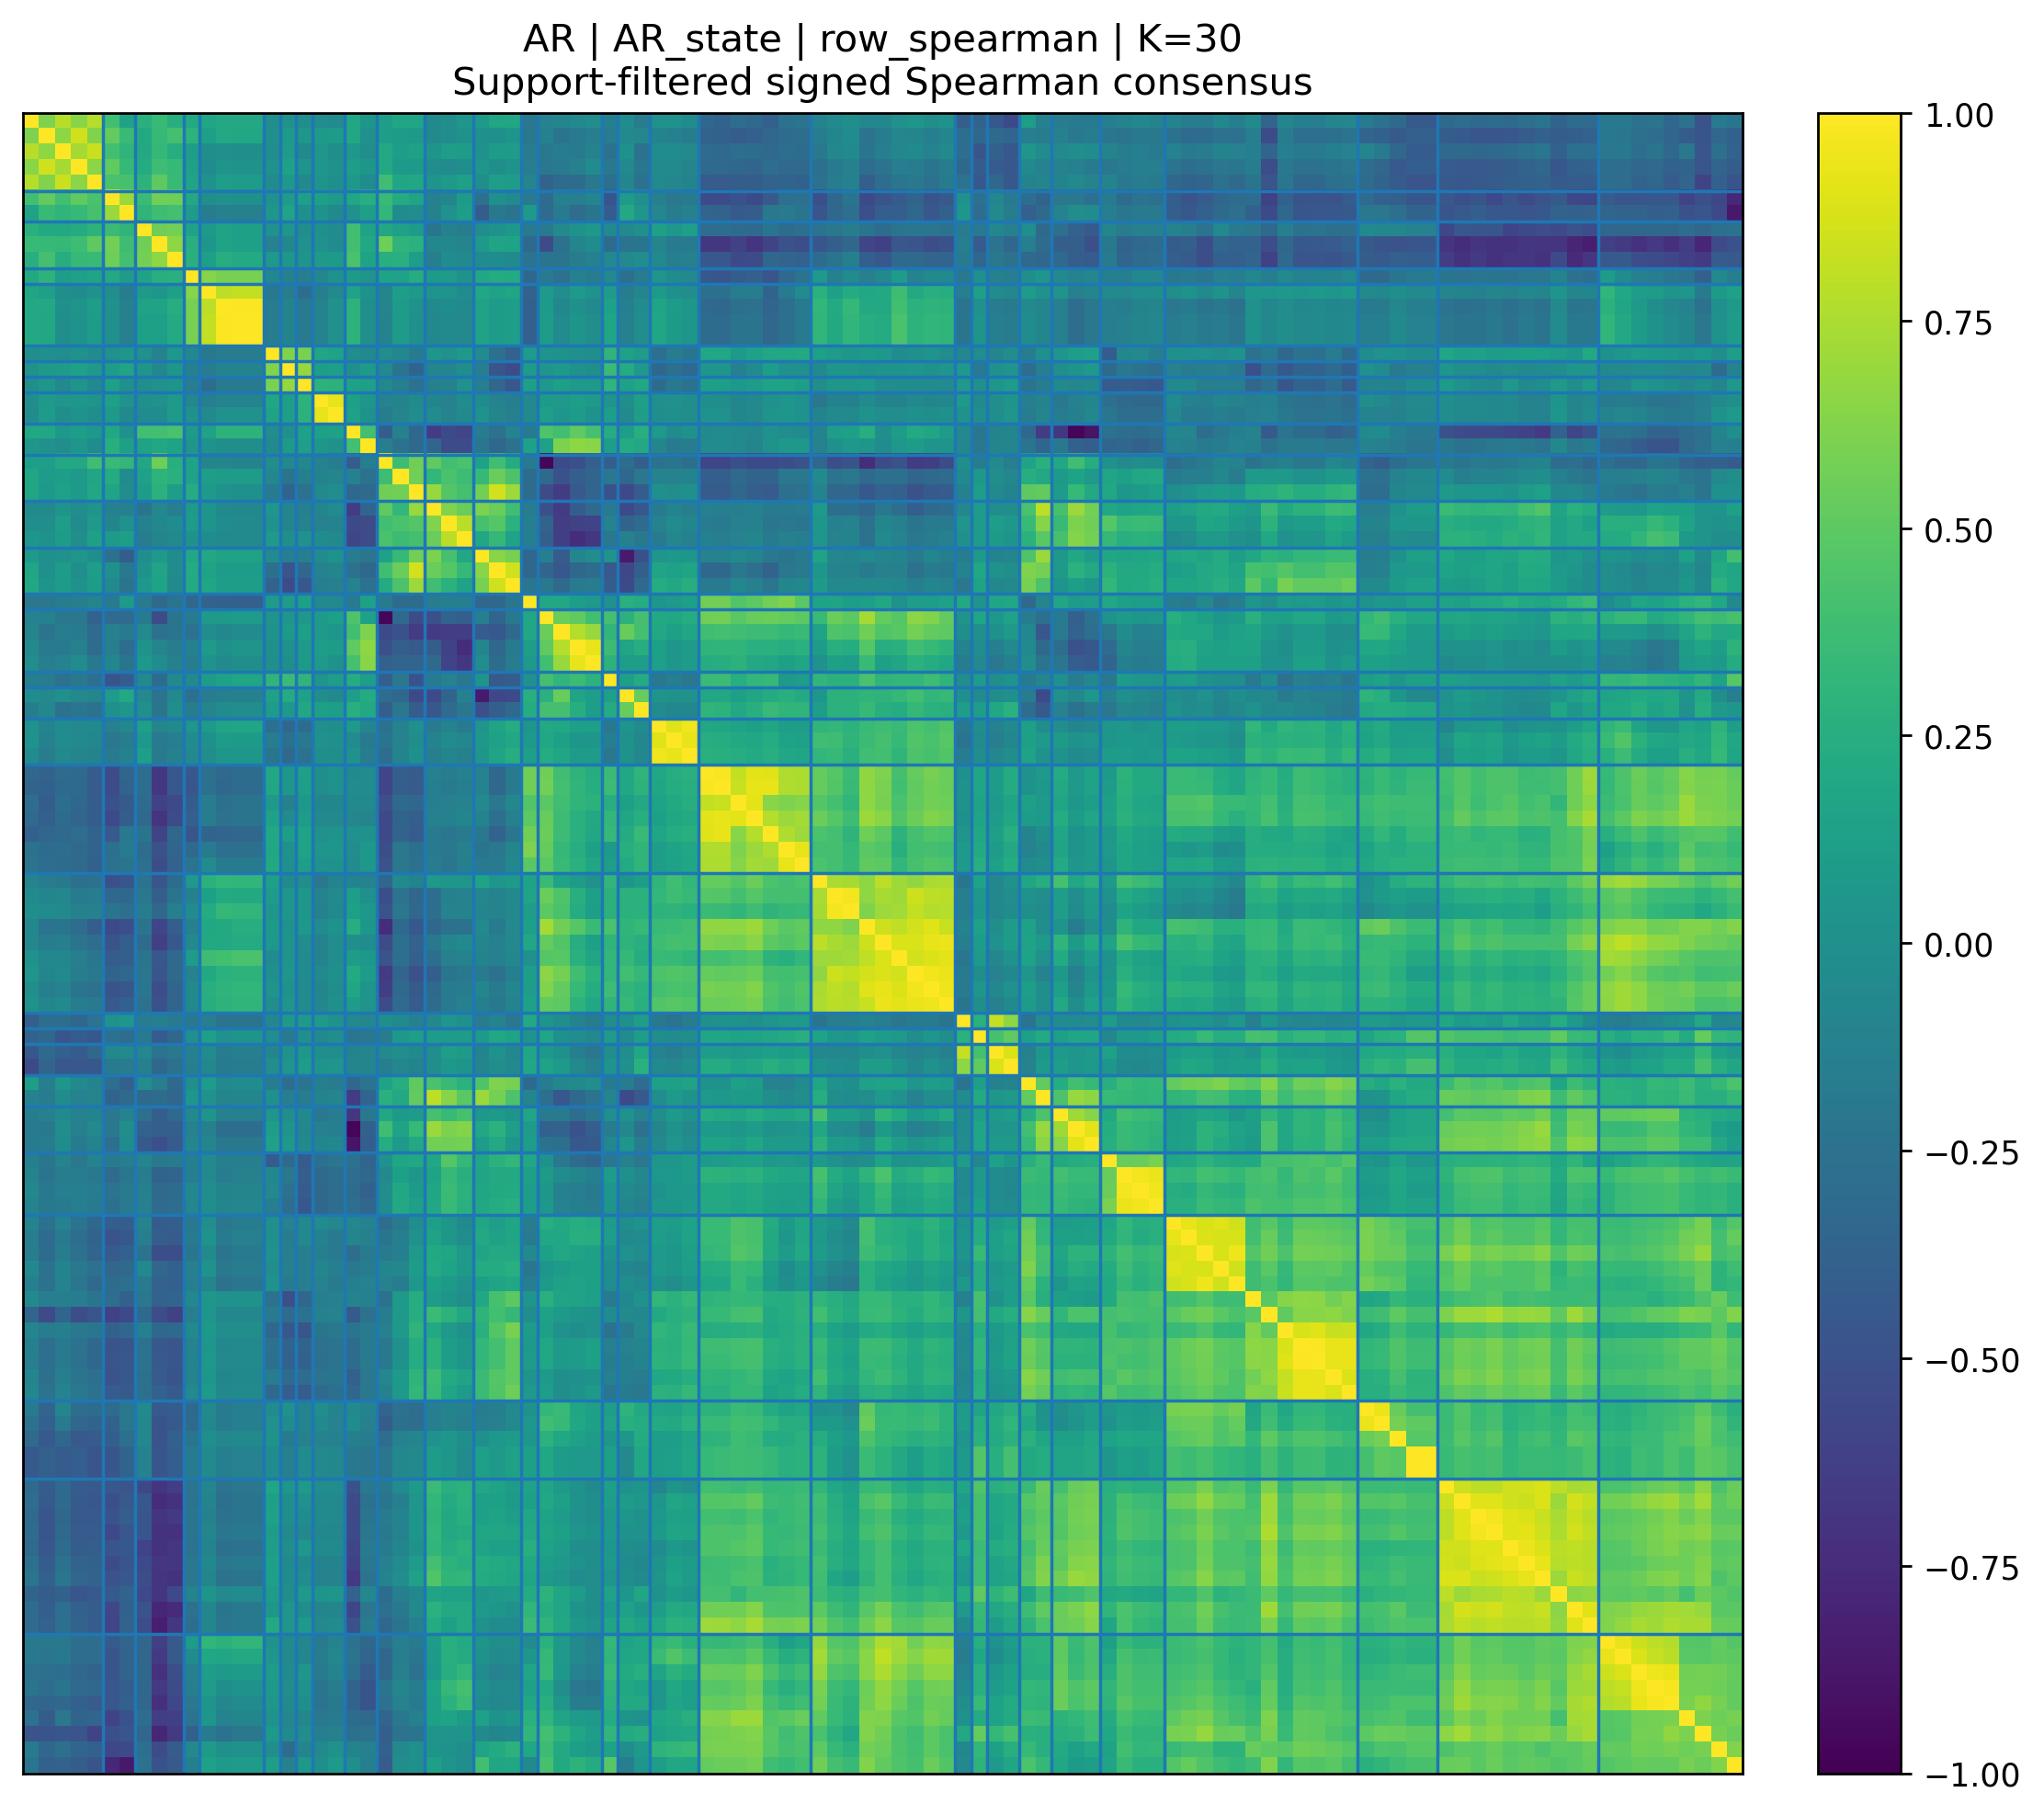

In [9]:
# ============================================================
# Cell 6 — Inspect one panel × prep root
# ============================================================

from IPython.display import Image, display

PANEL = "AR"
ROOT_NAME = "AR_state"
MODE = PRIMARY_MODE

summary = b2.show_root_summary(
    review,
    panel=PANEL,
    root=ROOT_NAME,
    mode=MODE,
    top_n=15,
)
display(summary)

plot_dir = (
    OUT_ROOT / "roots" /
    f"{b2.safe_slug(PANEL)}__{b2.safe_slug(ROOT_NAME)}" /
    MODE / "plots"
)

for filename in [
    "00_k_review_dashboard.png",
    "01_statistical_silhouette.png",
    "02_semantic_silhouette.png",
    "03_semantic_coherence_raw_vs_null.png",
    "04_semantic_coherence_enrichment.png",
    "06_module_size_health.png",
    "07_within_module_consensus_rho.png",
    # "08_cross_cohort_reproducibility.png",
    # "09_k_composite_score.png",
]:
    p = plot_dir / filename
    if p.exists():
        print("\n", filename)
        display(Image(filename=str(p)))

print("\nTop candidate-K heatmaps:")
for p in sorted((plot_dir / "top_k_heatmaps").glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))

In [10]:
# ============================================================
# Cell 7 — Compare row-Spearman primary vs direct-signed sensitivity
# ============================================================

mode_compare = review["recommendations"].copy()

cols = [
    "panel",
    "feature_source",
    "distance_mode",
    "n_features",
    "best_score_k",
    "recommended_parsimonious_k",
    "best_score",
    "recommended_stat_silhouette",
    "recommended_primitive_coherence_enrichment",
    "recommended_tissue_coherence_enrichment",
    "recommended_metric_coherence_enrichment",
    "recommended_max_cluster_fraction",
    "recommended_singleton_fraction",
    "recommended_q25_module_mean_consensus_rho",
    "recommended_median_module_fraction_positive_pairs",
    "recommended_passes_direct_cohesion_review",
    "recommended_cross_cohort_median_rho",
]
cols = [c for c in cols if c in mode_compare.columns]

display(
    mode_compare[cols]
    .sort_values(["panel", "feature_source", "distance_mode"])
    .reset_index(drop=True)
)

,panel,feature_source,distance_mode,n_features,best_score_k,recommended_parsimonious_k,best_score,recommended_stat_silhouette,recommended_primitive_coherence_enrichment,recommended_tissue_coherence_enrichment,recommended_metric_coherence_enrichment,recommended_max_cluster_fraction,recommended_singleton_fraction,recommended_q25_module_mean_consensus_rho,recommended_median_module_fraction_positive_pairs,recommended_passes_direct_cohesion_review,recommended_cross_cohort_median_rho
0,AR,AR_checkpoint_state,direct_signed,22,3,2,0.811250,0.636717,0.004297,0.013107,0.010316,0.727273,0.000000,0.407114,0.995833,True,0.442968
1,AR,AR_checkpoint_state,row_spearman,22,7,7,0.768750,0.658783,0.006139,0.050372,0.052424,0.500000,0.285714,0.523642,1.000000,True,0.650278
2,AR,AR_state,direct_signed,107,30,28,0.912069,0.429724,0.308469,0.363896,0.379849,0.130841,0.250000,0.675365,1.000000,True,0.701631
3,AR,AR_state,row_spearman,107,30,30,0.914655,0.520830,0.279408,0.311551,0.322495,0.112150,0.266667,0.608963,1.000000,True,0.644007
4,AR,compartment,direct_signed,37,19,19,0.803879,0.576204,0.450936,0.438817,0.479491,0.189189,0.368421,0.906975,1.000000,True,0.912509
5,AR,compartment,row_spearman,37,13,13,0.776724,0.700082,0.346298,0.343182,0.368068,0.189189,0.307692,0.764534,1.000000,True,0.840578
6,AR,compartment_state,direct_signed,93,29,29,0.917672,0.465920,0.315121,0.349600,0.380606,0.150538,0.344828,0.704784,1.000000,True,0.742491
7,AR,compartment_state,row_spearman,93,26,24,0.746121,0.473987,0.234601,0.255580,0.278426,0.172043,0.291667,0.540449,1.000000,True,0.636148
8,AR,phenotype_only,direct_signed,48,18,18,0.795690,0.596110,0.318249,0.310448,0.351156,0.145833,0.277778,0.777871,1.000000,True,0.786672
9,AR,phenotype_only,row_spearman,48,27,26,0.698707,0.495028,0.297090,0.318037,0.378135,0.104167,0.576923,0.788091,1.000000,True,0.836352


In [ ]:
# ============================================================
# Cell 8 — OPTIONAL: freeze final K after reviewing every root
# ============================================================

# Leave empty until the diagnostic review is complete.
FINAL_K = {
    # ("AR", "phenotype_only"): ...,
    # ("AR", "AR_state"): ...,
    # ("AR", "AR_checkpoint_state"): ...,
    # ("AR", "compartment"): ...,
    # ("AR", "compartment_state"): ...,
    # ("BT", "phenotype_only"): ...,
    # ("BT", "compartment"): ...,
}

if FINAL_K:
    frozen = b2.save_manual_k_selections(
        OUT_ROOT / "stage2b2_manual_k_review_template.csv",
        FINAL_K,
        OUT_ROOT / "stage2b2_final_k_selections.csv",
    )
    display(frozen)
    print("Saved:", OUT_ROOT / "stage2b2_final_k_selections.csv")
else:
    print("FINAL_K is empty — nothing frozen yet.")